In [1]:
import os
from bs4 import BeautifulSoup
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from googleapiclient.discovery import build
from langdetect import detect_langs
import time
import re
import random
from datasets import load_dataset
from huggingface_hub import login
from popular_ru_kaz import popular_ru_kaz_dict
from essential_ru_kaz import essential_ru_kaz_dict
import csv
from tqdm import tqdm
import fasttext
import asyncio
from telethon.tl.functions.messages import ImportChatInviteRequest
import emoji
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report
import torch
from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader
from torch.autograd import backward
from torch.optim import AdamW
import torch.nn.functional as F
from transformers import DataCollatorWithPadding
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from IPython.display import clear_output



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

C:\Users\nadgo\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cpu


# KazNLP — main notebook

**Parts:** 1) Synthetic FastText LID · 2) YouTube / Telegram collection · 3) Heuristic quality check · 4) Experiments (v2, Lingua, Kaspi) · 5) Cleaning

Dataset map → see [README.md](README.md). Column `language` = auto FastText, not human tone. Column `label` is unused.

Run Jupyter from **project root** so relative paths work.


## Dataset map (files on disk)

| Path | Role |
|------|------|
| `data/raw/telegram_code-switch_dataset.csv` | Raw Telegram, auto `language` |
| `data/processed/telegram_code-switch_v2.csv` | Relabel pass (`language_v2`) |
| `data/processed/mixed_heuristic_seed.csv` | Heuristic mixed seeds (~868) |
| `data/processed/lingua_candidates.csv` | Lingua filter experiment |
| `data/processed/kaspi_reviews.csv` | Kaspi reviews + ratings |
| `training/fasttext_synthetic.txt` | Synthetic LID training only |
| `models/fasttext_v1.bin`, `fasttext_v2.bin` | LID checkpoints |


# 1. FastText for language classification

If we try to create a naive approach of language assigning for a text (kaz, ru or mixed), the first idea is checking if a text contains special kazakh letters (әіңғүұқөһ). For Russian langueage it would be great to set a threshold for classifying a language as Russian. If there will be a lot of Cyrillic  letters in a text, the likelihood of being Russian language will exceed the threshold, so we can make a language classification. Then, texts with mixed languages (ru + kaz) could be detrmined through checking if a text contains both languages. 

However, there are some problems:

1. `Kazakh and Russian are too similar`. There are 42 letters in the kazakh alphabet and 33 of them are russian, so languages share 75% of their orthography. It means that normal kazakh speech will have high likelihood of being Russian language due to significant amont of Cyrillic  letters, so the classification result will be 'mixed'.
2. `Writing kazakh with no kazakh`. For instance, there is a simple kazakh sentence: **'Мен мектепке барамын'**. As you can see, there is no any kazakh letters, so there is no way that the alghoritm will classify the language of the sentence as 'kaz'.
3. `Lack of structural logic`. The current approach works on the principal **'if there is a letter N and the probability M, the language is L'**. Nevertheless, real mixed language is not just set of rules; It is about building a russian language sentence using kazakh logic, words from both languages and vice versa. 
    

Owing to negatives of the naive approach, language classification will not be accurate. If we want a clear and correct dataset, we need to use a pretrained model, fine-tuned on real kaz/ru samples and synthetic mixed languages samples. I decided to use FastText as a baseline model. **FastText** — supervised LID baseline: text is represented as **word n-grams** (unigrams + bigrams), then a shallow linear classifier picks `ru` / `kz` / `mixed`. In theory, this approach should ensure a properly structured dataset because of these positives:

1. `Context awareness`. Due to deep learning approach, a model sees a clear structure of a sentence despite letters. For example, words **'калайсын'** and **'қалайсың'** will be both classified as 'kaz'. During the learning process a model understands that both of the words are used in the same context with a specific language.
2. `Robustness to Code-Switching Variations`. Most users on social media neglect the specific characters of the Kazakh alphabet (ә, і, ң, etc.), using the standard Cyrillic keyboard layout.
3. `Methodological Objectivity`. Filtering by letters artificially restricts the dataset to only those messages written in strict accordance with orthography. This distorts the results of semantic analysis, making it applicable only to a ‘formal’ style.

## 1.1 Creating a dataset for training FastText
**Kazakh** texts were taken from the 'KazSAnDRA' dataset

**Russian** texts were taken from the russian part of the 'clap AI MultiLingualSentiment' dataset

**Mixed** texts were created synthetically

In [37]:
def remove_operators(example): # a function for removing escaped sequences
    text = str(example['text'])

    text = text.replace('\\n', ' ') # remove literal
    text = re.sub(r'[\n\r\t]+', ' ', text) # remove real 
    text = re.sub(r'\s+', ' ', text) # double spaces into the one
    
    example['text'] = text.strip()

    return example

Loading data

In [77]:
login(os.environ['HF_TOKEN'])  # set in .env; rotate old leaked tokens

raw_ru_data = load_dataset('clapAI/MultiLingualSentiment')
raw_kaz_data = load_dataset('issai/kazsandra', 'full')

ru_data = raw_ru_data['train'].filter(lambda x: x['language'] == 'ru')
kaz_data = raw_kaz_data['train']

ru_data = ru_data.map(remove_operators)
kaz_data = kaz_data.map(remove_operators)


In [ ]:
print(f'KAZ data:\n{kaz_data}')
print('\n')
print(f'RU data:\n{ru_data}')

KAZ data:
Dataset({
    features: ['custom_id', 'text', 'label', 'domain'],
    num_rows: 180064
})


RU data:
Dataset({
    features: ['text', 'label', 'source', 'domain', 'language'],
    num_rows: 164148
})


In [78]:
kaz_texts = [i['text'] for i in kaz_data]
ru_texts = [i['text'] for i in ru_data]

In [ ]:
print(f'KAZ sample:\n{kaz_texts[0]}')
print('\n')
print(f'RU sample:\n{ru_texts[0]}')

KAZ sample:
Тамақтарыңыз өте дәмді екен. Көп көп рақмет


RU sample:
Всем здравствуйте. Заказывал помощь. Очень доволен точто зашёл именно на этот сайт. Работники вежливые всё внятно объяснили. Можно быстро дозвониться до рабочих. Плюсы: Качественноя работа, можно быстро дозвониться, приемлемые цены. Минусы: долго выявляют причину поломки. Ещё хочу сказать что пользуюсь сайтом не в первые всегда выевляют причину Мне кажется сайт подойдёт абсолютно всем. Всем советую!!!


 ~500 the most essential kazakh words with russian translation and 1500+ the most popular russian words with kazakh translation 

In [79]:
popular_ru = popular_ru_kaz_dict
essential_kaz = essential_ru_kaz_dict

print('Samples from popular_ru:')
for ru, kz in list(popular_ru.items())[:10]:
    print(f'{ru} ---> {kz}')

print('\n')

print('Samples from essential_kaz:')
for ru, kz in list(essential_kaz.items())[:10]:
    print(f'{ru} ---> {kz}')

Samples from popular_ru:
и ---> және
в ---> ішінде
не ---> емес
на ---> үстінде
я ---> мен
он ---> ол
что ---> не
это ---> бұл
быть ---> болу
а ---> ал


Samples from essential_kaz:
луна ---> ай
чайник ---> аккуман
яблоко ---> алма
апельсин ---> апельсин
пчела ---> ара
остров ---> арал
арка ---> арка
драгоценный камень ---> асыл тас
больница ---> аурухана
рот ---> ауыз


In [80]:
master_dict = {**popular_ru, **essential_kaz} # popular_ru + essential_kaz

In [81]:
KAZ_TAGS = [
    # questionable
    'ма', 'ба', 'па', 'ме', 'бе', 'пе', 'ше', 
    'ғой', 'ғо', 'го', 'гой', 'қо', 'ко', 'қой', 'кой', 'да', 'де', 'та', 'те',
    'негізі', 'негизи', 'сосын', 'зато', 'бірақ', 'бирак',

    # emotional
    'иә', 'я', 'ия','е', 'а', 'әй', 'ойбай', 'обал', 'масқара', 'маскара',
    'шүкір', 'шукир', 'тәубе', 'таубе', 'жоқ', 'жок', 'мақұл', 'макул',
    
    # slang
    'қысқасы', 'кыскасы', 'негізінен', 'анау', 'мынау', 'жаңағы', 'жанагы' 
]


KAZ_AFFIXES = [
    # plural
    "лар", "лер", "дар", "дер", "тар", "тер",

    # cases (in, on, to, from, with, of whom/of what)
    "да", "де", "та", "те", "ға", "ге", "қа", "ке", "га", "ге", "ка", "ке",
    "дан", "ден", "тан", "тен", "нан", "нен",
    "ны", "ні", "ды", "ді", "ты", "ті", "ны", "ни", "ды", "ди", "ты", "ти",
    "ның", "нің", "дын", "дің", "тын", "тін", "нын", "нин", "дын", "дин",

    # possessive endings (my, your, our, your, his)
    "ым", "ім", "ың", "ің", "иым", "иим", "ын", "ин",
    "ымыз", "іміз", "ыңыз", "іңіз", "иымыз", "иимиз",
    "ныкы", "нікі", "ныки", "ники",

    # personal endings (I am, you are - for slang like 'красавчиксын')
    "мын", "мін", "бын", "бін", "пын", "пін",
    "сың", "сің", "сыз", "сіз", "сын", "син", "сыз", "сиз",

    # negation and quality
    "сыз", "сіз", "сыз", "сиз", "лық", "лік", "лык", "лик"
]

## 1.2 Functions for creating synthetic mixed

In [ ]:
def clean_word(word):
    'Removes punctuation and symbols for clean dictionary lookup'
    return re.sub(r'[^\w\s]', '', word.lower())

def generate_mixed_sample(ru_text, kz_text):
    strategy = random.choices(
        ['substitution', 'tag', 'affix', 'concat'], 
        weights=[0.35, 0.30, 0.20, 0.15]
    )[0]
    
    ru_words = ru_text.split()
    if not ru_words: return kz_text

    if strategy == 'substitution':
        new_words = []
        for w in ru_words:
            cw = clean_word(w)
            if cw in master_dict and random.random() < 0.6:
                new_words.append(master_dict[cw])
            else:
                new_words.append(w)
        return ' '.join(new_words)

    elif strategy == 'tag':
        tag = random.choice(KAZ_TAGS)
        return f'{ru_text.rstrip(".?!")} {tag}' if random.random() > 0.5 else f'{tag} {ru_text.lower()}'

    elif strategy == 'affix':
        candidates = [i for i, w in enumerate(ru_words) if len(clean_word(w)) > 5]
        if candidates:
            idx = random.choice(candidates)
            affix = random.choice(KAZ_AFFIXES)
            clean_target = clean_word(ru_words[idx])
            ru_words[idx] = f"{clean_target}{affix}"
        return " ".join(ru_words)

    elif strategy == 'concat':
        ru_part = ' '.join(ru_words[:len(ru_words)//2 + 1])
        kz_words = kz_text.split()
        kz_part = ' '.join(kz_words[len(kz_words)//2:])
        return f'{ru_part} {kz_part}'
    

# dataset complation
def create_mixed_dataset_to_file(ru_list, kz_list, output_path, target_size=160000):
    '''
    Takes lists of strings (RU and KZ), generates synthetic mixed data, 
    and saves the final balanced dataset to a FastText-ready .txt file.
    '''
    print(f'Starting dataset generation. Target per class: {target_size}')
    
    # Downsampling to ensure perfect 1:1:1 balance
    # Using min() to avoid errors if one list is smaller than target_size
    current_target = min(len(ru_list), len(kz_list), target_size)
    
    print(f'Downsampling source lists to {current_target} samples...')
    ru_final = random.sample(ru_list, current_target)
    kz_final = random.sample(kz_list, current_target)
    
    mixed_final = []
    
    # Synthetic MIXED class generation
    print(f'Generating {current_target} mixed samples using weighted strategies...')
    for i in range(current_target):
        # Pick random references for the generator
        ru_ref = random.choice(ru_final)
        kz_ref = random.choice(kz_final)
        
        # generate_mixed_sample must be defined in your notebook
        mixed_str = generate_mixed_sample(ru_ref, kz_ref)
        mixed_final.append(mixed_str)
        
        if (i + 1) % 20000 == 0:
            print(f'Progress: {i + 1} / {current_target} mixed samples created')

    # Labeling and merging
    print('Labeling and shuffling...')
    dataset = []
    for line in ru_final:
        dataset.append(f'__label__ru {line}')
    for line in kz_final:
        dataset.append(f'__label__kz {line}')
    for line in mixed_final:
        dataset.append(f'__label__mixed {line}')
        
    # Shuffle the final dataset so labels are not grouped
    random.shuffle(dataset)
    
    # Writing directly to file
    print(f'Writing final dataset to: {output_path}')
    with open(output_path, 'w', encoding='utf-8') as f:
        for entry in dataset:
            f.write(f'{entry}\n')
            
    print(f'Success! Total lines written: {len(dataset)}')
    print(f'Classes: ru({current_target}), kz({current_target}), mixed({current_target})')


create_mixed_dataset_to_file(ru_texts, kaz_texts, 'training/fasttext_synthetic.txt', target_size=160000)


Starting dataset generation. Target per class: 160000
Downsampling source lists to 160000 samples...
Generating 160000 mixed samples using weighted strategies...
Progress: 20000 / 160000 mixed samples created
Progress: 40000 / 160000 mixed samples created
Progress: 60000 / 160000 mixed samples created
Progress: 80000 / 160000 mixed samples created
Progress: 100000 / 160000 mixed samples created
Progress: 120000 / 160000 mixed samples created
Progress: 140000 / 160000 mixed samples created
Progress: 160000 / 160000 mixed samples created
Labeling and shuffling...
Writing final dataset to: fasttext_synthetic_data.txt
Success! Total lines written: 480000
Classes: ru(160000), kz(160000), mixed(160000)


In [ ]:
print(f"{'STRATEGY':<15} | {'GENERATED MIXED SAMPLE'}")
print("-" * 60)

for strategy in ['substitution', 'tag', 'affix', 'concat']:
    test_ru = random.choice(ru_texts)
    test_kz = random.choice(kaz_texts)

    sample = generate_mixed_sample(test_ru, test_kz) 
    print(f"{strategy:<15} | {sample}")

STRATEGY        | GENERATED MIXED SAMPLE
------------------------------------------------------------
substitution    | Жаль, не к специалистам болады түсу тек через терапевта. Порадовало, не қарай урологу попала по явке практически минут в минуту все 2 раза)))
tag             | жанагы маломерит на 2 размера, качество ткани как раз на эту стоимость
affix           | Самое отвратительное орындык ішінде которых біз были. Снимая домик, нам был обещан бассейн душ, комфортабельный двухэтажный домик. бойынша факту домик өте кішкентай үшін үлкен компании, ішінде домике стоит холодильник, қайсы не закрывается. лас с водой внутри. Когда включали в розетку, искрило, как үстінде салюте. Боялись, что замкнет. Из четырех розеток работало только үш Внутри было грязно, емес убрано. да чайника, да посуды жоқ от слова совсем. Постельное белье, как в поезде, за акша Горячий душ тоже платный. Есть бесплатный, бірақ ол без крыши в раздевалке жане без дверей. Одна раковина на весь "колхоз". онда да и умыва

## 1.3 Train/Test split

In [86]:
def split_fasttext_file(input_path, train_path, test_path, test_size=0.2):

    with open(input_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    random.shuffle(lines)
    
    split_idx = int(len(lines) * (1 - test_size))
    
    train_data = lines[:split_idx]
    test_data = lines[split_idx:]
    
    with open(train_path, 'w', encoding='utf-8') as f:
        f.writelines(train_data)
        
    with open(test_path, 'w', encoding='utf-8') as f:
        f.writelines(test_data)
        
    print(f"Total samples: {len(lines)}")
    print(f"Train: {len(train_data)}")
    print(f"Test: {len(test_data)}")

# Используем
split_fasttext_file('training/fasttext_synthetic.txt', 'training/train_synthetic.txt', 'training/test_synthetic.txt', test_size=0.2)


Total samples: 480000
Train: 384000
Test: 96000


## 1.4 Training and Evaluation

In [87]:
# 1. Training the model
# input: path to your generated file
# epoch: number of passes over the data (30-50 is good for 480k samples)
# lr: learning rate (0.1 - 0.5 is standard)
# wordNgrams: allows the model to see word combinations (e.g., "орындык жане")
# dim: vector size (100 is default, enough for this task)

print("Training started...")
model = fasttext.train_supervised(
    input="training/train_synthetic.txt", 
    epoch=30, 
    lr=0.4, 
    wordNgrams=2, 
    verbose=2, 
    minCount=1,
    dim=100
)
print("Training finished!")

# 2. Evaluation
# Returns a tuple: (number of samples, precision, recall)
def print_results(N, p, r):
    print(f"Samples: {N}")
    print(f"Precision: {p:.4f}")
    print(f"Recall: {r:.4f}")
    print(f"F1-score: {(2 * p * r / (p + r)):.4f}")

print("\n--- Model Performance ---")
print_results(*model.test("training/test_synthetic.txt")) 

# 3. Quick Manual Test
test_sentences = [
    "Свитер очень классный жане теплый",          # Mixed
    "Мен бүгін мектепке барамын",                  # Kaz
    "Завтра будет очень солнечная погода",        # Ru
    "Проблемасын шештик"                          # Mixed (with affix)
]

print("\n--- Manual Predictions ---")
for text in test_sentences:
    # predict returns ([label], [probability])
    label, prob = model.predict(text.lower())
    print(f"Text: {text} \nPrediction: {label[0]} (Prob: {prob[0]:.2f})\n")

# 4. Save the model for future research/use
model.save_model("models/fasttext_v1.bin")
print("Model saved")


Training started...
Training finished!

--- Model Performance ---
Samples: 96000
Precision: 0.8496
Recall: 0.8496
F1-score: 0.8496

--- Manual Predictions ---
Text: Свитер очень классный жане теплый 
Prediction: __label__mixed (Prob: 1.00)

Text: Мен бүгін мектепке барамын 
Prediction: __label__kz (Prob: 1.00)

Text: Завтра будет очень солнечная погода 
Prediction: __label__mixed (Prob: 0.97)

Text: Проблемасын шештик 
Prediction: __label__kz (Prob: 1.00)

Model saved


---
# 2. Collecting Data (1)

Collecting YouTbe comments, filter them and organise to a final dataset with 3 columns: , `text`, `language`, `label`

## 2.1 YouTube

In [ ]:
class KazakhDataCollector:
    def __init__(self, api_key, model_path='models/models/fasttext_v1.bin'):
        self.youtube = build('youtube', 'v3', developerKey=api_key)
        # Загружаем твою обученную модель
        self.model = fasttext.load_model(model_path)

    def detect_lang(self, text):
        """
        Использует твою обученную модель FastText для классификации.
        """
        # Базовая очистка текста (как при обучении)
        clean_text = text.replace('\n', ' ').lower().strip()
        
        if not clean_text:
            return 'other'
            
        try:
            # Предсказываем метку
            label, prob = self.model.predict(clean_text)
            # label выглядит как '__label__mixed'
            lang = label[0].replace('__label__', '')
            
            # Если уверенность модели низкая (меньше 0.6), помечаем как 'other'
            if prob[0] < 0.6:
                return 'other'
                
            return lang
        except Exception as e:
            print(f"Ошибка классификации: {e}")
            return 'other'

    def filter_comments(self, comments):
        out = []
        for c in comments:
            t = c['text']
            
            # Фильтр: минимум 3 слова, нет ссылок, достаточное кол-во уникальных символов
            if len(t.split()) < 3 or 'http' in t or len(set(t)) < 5:
                continue
                
            lang = self.detect_lang(t)
            
            # Теперь мы сохраняем и КАЗ, и МИКС (все, кроме РУ и OTHER)
            if lang in ('kz', 'mixed'):
                c['lang_type'] = lang
                c['sentiment'] = '' # Оставим поле для будущего анализа настроений
                out.append(c)
        
        return out
    

    def collect_from_channels(self, channel_ids, videos_per_channel=50):
        for c_id in channel_ids:
            # 1. Получаем ID плейлиста со всеми загрузками канала
            ch_res = self.youtube.channels().list(part='contentDetails', id=c_id).execute()
            uploads_id = ch_res['items'][0]['contentDetails']['relatedPlaylists']['uploads']
            
            # 2. Выкачиваем список видео (дешево по квотам)
            v_req = self.youtube.playlistItems().list(part='snippet', playlistId=uploads_id, maxResults=videos_per_channel)
            v_res = v_req.execute()
            
            for item in v_res['items']:
                v_id = item['snippet']['resourceId']['videoId']
                # Дальше твой collect_comments и filter_comments


In [ ]:
collector = KazakhDataCollector(api_key=API_KEY)
df = collector.run(
    queries=[
        'Казахстан жаңалықтар',
        'қазақ фильм',
        'Алматы',
        'Астана',
        'қазақ музыка',
        'саясат Қазақстан',
        'Қазақ әндері',
        'Димаш Құдайберген',
        'Қазақстан',
        'jurttyn balasy',
        'Қазақстан конституциясы',
        'Қасым Жомарт Тоқаев',
        'История Казахстана',
        "қазақ тамақ рецепт",      
        "футбол Қазақстан",        
        "мектеп университет",      
        "жаңа жыл",
        "қазақ юмор"],
        
    save_path='kazakh_sentiment_raw.csv'
)




Казахстан жаңалықтар: 10 видео
5JE8gUIaWRQ: 20 -> 17
IUuaV6FsbeQ: 3 -> 2
ZAa_pSjxCoc: 1 -> 0
i2f3YZ-VzmQ: 14 -> 7
lKX-rgSYgHU: 0 -> 0
0y0ngkvyj_U: 38 -> 20
848XycufPYM: 7 -> 1
LUI9JJXjwfc: 0 -> 0
dIjKTy3SFgE: 2 -> 1
NB9aVD_esg8: 0 -> 0

қазақ фильм: 10 видео
2FekuzQjVvU: 200 -> 88
KQ9rGe4idIk: 200 -> 107
2NXpY-th1zk: 200 -> 27
RU-o3BMhlTU: 51 -> 15
xtAVbk9Adyk: 200 -> 96
jGtlNNsnZQ4: 200 -> 114
CqdhWrDAHvM: 179 -> 2
oe3PTMPlr-0: 200 -> 95
6TNdzONfU2c: 24 -> 8


KeyboardInterrupt: 

In [ ]:
df = pd.read_csv("kazakh_sentiment_raw.csv")

print("=== MIXED примеры ===")
print(df[df["lang_type"] == "mixed"]["text"].sample(10).to_string())

print("\n=== KAZ примеры ===")
print(df[df["lang_type"] == "kaz"]["text"].sample(10).to_string())

df["len"] = df["text"].apply(lambda x: len(x.split()))
print("\n=== Длина ===")
print(df.groupby("lang_type")["len"].describe())

=== MIXED примеры ===
2109    Невероятной красоты песня!!! Чем больше слушаю...
2716     Алтынбек Сарсенбаев жатқан жеріңіз жайлы болсын🤲
3270    Рахмет күшті. Үйінде 5 адамнан көп тұратын ада...
3034    Сөз саптауы керемет, орыс тілінде бар болғаны ...
17      Егер елімізде діншілдер көбейсе ақырын ақырын ...
4620                    Сол ғо физикалық  прикол болды ғо
3805    Намбияны утсак онда футболымыздың деңгейі өсіп...
3897    Осындайдын 3-4 болса, қақпада Темірлан тұрса б...
4136        Келе жатқан 2025 бақытты сәттер көп болсын 💋🙈
746     Адамдардың жастары сәйкескелмейт.жиырмасыншы ж...

=== KAZ примеры ===
2546              Арука Ернатқа әпкеме тисе бермеңіз деді
1927    Бәрібірорыстілінде сөйдегеді қазақ тіліне басқ...
275                      Өте әсерлі фильм күшті күшті 👍👍👍
4686                         Мен тір кел дім лайк бас тым
3553    Гарнирді жұлдызша формаға салсаң ет ай сияқты ...
2266    Ну ніяк не можу наслухатися наскільки голос до...
4566                Красавчик

## 2.2 Collecting news channels comments from Telegram
From this messenger I will collect comments from the most popular channels among kazakh community

In [4]:
import os
api_id = int(os.environ.get('TELEGRAM_API_ID', '0'))
api_hash = os.environ.get('TELEGRAM_API_HASH', '')
client = TelegramClient('sessions/data_collection', api_id, api_hash)


Collecting data from these channels

In [ ]:
kz_channels = ['tengrinews', 'zakonkz', 'newsnurkz', 'the_steppe', 'qazaqstantv', 'ztb_qaz', 'podeshevlekz', 'jurttyn_balasy']

In [40]:
# Telethon collection — appends to data/raw/telegram_code-switch_dataset.csv
# language column = FastText at collect time, not ground truth
from telethon.errors import FloodWaitError


ft = fasttext.load_model('models/models/fasttext_v1.bin') # loading fine-tuned FastText model

total_mixed = 0
mixed_counts = {channel: 0 for channel in kz_channels}



async def data_collection():
    channels = await client.get_entity(kz_channels)
    global total_mixed

    with open('data/raw/telegram_code-switch_dataset.csv', 'w', encoding='utf-8', newline='') as f:
        fieldnames = ['text', 'language', 'label']
        writer = csv.DictWriter(f, fieldnames=fieldnames, restval='')
        writer.writeheader()


        for channel in channels:
            await asyncio.sleep(5)

            async for post in client.iter_messages(channel):
                print(f'Collecting from "{channel.title}" | Post {post.id} | Mixed: {total_mixed}', end='\r')
                
                try:
                    async for comment in client.iter_messages(channel, reply_to=post.id):
                        if comment.text:
                            language = ft.predict(comment.text)[0][0].replace('__label__', '')
                            writer.writerow({'text': comment.text,
                                            'language': language})
                            
                            if language == 'mixed':
                                mixed_counts[channel.username] += 1
                                total_mixed = sum(mixed_counts.values())

                            await asyncio.sleep(0.3)

                except FloodWaitError as e:
                    print(f'Flood Error: waiting for {e.seconds} seconds')
                    await asyncio.sleep(e.seconds)
                except Exception:
                    continue

async with client:
    await data_collection()


Server closed the connection: [WinError 10054] Удаленный хост принудительно разорвал существующее подключение


Telegram is having internal issues RpcMcgetFailError: Telegram is having internal issues, please try again later. (caused by GetRepliesRequest)
Telegram is having internal issues RpcMcgetFailError: Telegram is having internal issues, please try again later. (caused by GetRepliesRequest)


CancelledError: 

`Zakon.kz` channel is too big. The collecting process was stopped to collect data from other channels with purpose making dataset more various

Remove `Zakon.kz` and `Tengrinews.kz` from **kz_channels**

In [51]:
kz_channels = ['newsnurkz', 'the_steppe', 'qazaqstantv', 'ztb_qaz', 'podeshevlekz', 'jurttyn_balasy']

Collecting script

In [42]:
# Telethon collection — appends to data/raw/telegram_code-switch_dataset.csv
# language column = FastText at collect time, not ground truth
from telethon.errors import FloodWaitError


ft = fasttext.load_model('models/models/fasttext_v1.bin') # loading fine-tuned FastText model



async def data_collection():
    channels = await client.get_entity(kz_channels)
    global total_mixed

    with open('data/raw/telegram_code-switch_dataset.csv', 'a', encoding='utf-8', newline='') as f:
        fieldnames = ['text', 'language', 'label']
        writer = csv.DictWriter(f, fieldnames=fieldnames, restval='')


        for channel in channels:
            await asyncio.sleep(5)

            async for post in client.iter_messages(channel, limit=10000):
                print(f'Collecting from "{channel.title}" | Post {post.id} | Mixed: {total_mixed}', end='\r')
                
                try:
                    async for comment in client.iter_messages(channel, reply_to=post.id):
                        if comment.text:
                            language = ft.predict(comment.text)[0][0].replace('__label__', '')
                            writer.writerow({'text': comment.text,
                                            'language': language})
                            
                            if language == 'mixed':
                                mixed_counts[channel.username] += 1
                                total_mixed = sum(mixed_counts.values())

                            await asyncio.sleep(0.3)

                except FloodWaitError as e:
                    print(f'Flood Error: waiting for {e.seconds} seconds')
                    await asyncio.sleep(e.seconds)
                except Exception:
                    continue

async with client:
    await data_collection()


1st wave collection results

In [43]:
dc_results = pd.DataFrame(mixed_counts, index=['Mixed'])

highest_mixed_col = dc_results.iloc[0].idxmax()
lowest_mixed_col = dc_results.iloc[0].idxmin()

print(f'The HIGHEST "mixed" were found in {highest_mixed_col} {dc_results[highest_mixed_col].values}\n')
print(f'The LOWEST "mixed" were found in {lowest_mixed_col} {dc_results[lowest_mixed_col].values}\n')
print(f'TOTAL "mixed": {total_mixed}')

The HIGHEST "mixed" were found in zakonkz [14721]

The LOWEST "mixed" were found in tengrinews [0]

TOTAL "mixed": 16950


In [44]:
dc_results

,tengrinews,zakonkz,newsnurkz,the_steppe,qazaqstantv,ztb_qaz,podeshevlekz,jurttyn_balasy
Mixed,0,14721,0,0,0,0,2152,77


In [45]:
df = pd.read_csv('data/raw/telegram_code-switch_dataset.csv')

print(df.shape)
print(df['language'].value_counts())
print()
print(df.head(10))
print()
# примеры mixed
print('=== MIXED примеры ===')
print(df[df['language'] == 'mixed']['text'].sample(10).to_string())


(146206, 3)
language
ru       77790
kz       51466
mixed    16950
Name: count, dtype: int64

                                                text language  label
0           Солнце светит ярче только в рабочие дни😆       ru    NaN
1  Держите зонты и куртки наготове, погода опять ...    mixed    NaN
2            Придётся зонтик брать или дома сидеть 🌀       ru    NaN
3  Ну что, готовимся к непогоде, запасайтесь зонт...       kz    NaN
4                              Күздің қырсығы ғой 🌧️       kz    NaN
5  Всё лето ждёшь, а тут такие сюрпризы от природы 😅       ru    NaN
6                                            В точку       kz    NaN
7  Они платные ...и даже кто захочет,порой не мог...       ru    NaN
8  Потому что уровень образования хромает, те кто...       ru    NaN
9                                     Бородатая тема       kz    NaN

=== MIXED примеры ===
37505     Мы можем быть не просто сырьевыми поставщиками...
105303    Казахстан так масштабно себя показал,наши редк...
92653

The precision of the filter is too low: there are all **false positive** examples in the output.

Keep collecting data from the most "mixed" channel

In [48]:
# Telethon collection — appends to data/raw/telegram_code-switch_dataset.csv
# language column = FastText at collect time, not ground truth
kz_channels = ['zakonkz']
ft = fasttext.load_model('models/models/fasttext_v1.bin') # loading fine-tuned FastText model

total_mixed = 0
mixed_counts = {channel: 0 for channel in kz_channels}



async def data_collection():
    channels = await client.get_entity(kz_channels)
    global total_mixed

    with open('data/raw/telegram_code-switch_dataset.csv', 'a', encoding='utf-8', newline='') as f:
        fieldnames = ['text', 'language', 'label']
        writer = csv.DictWriter(f, fieldnames=fieldnames, restval='')


        for channel in channels:
            await asyncio.sleep(5)

            async for post in client.iter_messages(channel, offset_id=61203):
                print(f'Collecting from "{channel.title}" | Post {post.id}', end='\r')
                
                try:
                    async for comment in client.iter_messages(channel, reply_to=post.id):
                        if comment.text:
                            language = ft.predict(comment.text)[0][0].replace('__label__', '')
                            writer.writerow({'text': comment.text,
                                            'language': language})
                            
                            if language == 'mixed':
                                mixed_counts[channel.username] += 1
                                total_mixed = sum(mixed_counts.values())

                            await asyncio.sleep(0.3)

                except FloodWaitError as e:
                    print(f'Flood Error: waiting for {e.seconds} seconds')
                    await asyncio.sleep(e.seconds)
                except Exception:
                    continue

async with client:
    await data_collection()


Server closed the connection: [WinError 10054] Удаленный хост принудительно разорвал существующее подключение


Server closed the connection: [WinError 10054] Удаленный хост принудительно разорвал существующее подключение
Attempt 1 at connecting failed: TimeoutError: 
Attempt 2 at connecting failed: TimeoutError: 
Attempt 3 at connecting failed: TimeoutError: 
Attempt 4 at connecting failed: TimeoutError: 
Attempt 5 at connecting failed: TimeoutError: 
Attempt 6 at connecting failed: TimeoutError: 
Attempt 1 at connecting failed: TimeoutError: 
Attempt 2 at connecting failed: TimeoutError: 
Attempt 3 at connecting failed: TimeoutError: 
Attempt 4 at connecting failed: TimeoutError: 
Attempt 5 at connecting failed: TimeoutError: 
Attempt 6 at connecting failed: TimeoutError: 
Attempt 1 at connecting failed: TimeoutError: 
Attempt 2 at connecting failed: TimeoutError: 
Attempt 3 at connecting failed: TimeoutError: 
Attempt 4 at connecting failed: TimeoutError: 
Attempt 5 at connecting failed: TimeoutError: 
Attempt 6 at connecting failed: TimeoutError: 
Attempt 1 at connecting failed: TimeoutError

ConnectionError: Cannot send requests while disconnected

There is a mistake of the session disconnect. No need to restart the collection, lets watch the data set instead

In [49]:
df = pd.read_csv('data/raw/telegram_code-switch_dataset.csv')

print(df.shape)
print(df['language'].value_counts())
print()
print(df.head(10))
print()
# примеры mixed
print('=== MIXED примеры ===')
print(df[df['language'] == 'mixed']['text'].sample(10).to_string())


(241576, 3)
language
ru       126929
kz        87019
mixed     27628
Name: count, dtype: int64

                                                                                                                                                                  text  \
0                                                                                                                             Солнце светит ярче только в рабочие дни😆   
1                                                                                                               Держите зонты и куртки наготове, погода опять удивляет   
2                                                                                                                              Придётся зонтик брать или дома сидеть 🌀   
3                                                                                                      Ну что, готовимся к непогоде, запасайтесь зонтиками и терпением   
4                                                     

There is also very low precision. How many **true positive** has the dataset got?

Simple filter will perfectly deal with the task

In [57]:
# Narrow heuristic: both Kazakh special letters AND Russian Cyrillic
# Misses shala-Kazakh without ә/ң; use only as seed filter, not gold
kaz_specific = set('әіңғүұқөһ')

def is_real_mixed(text):
    text_lower = text.lower()
    has_kaz = any(c in kaz_specific for c in text_lower)
    has_rus = any(c in 'абвгдеёжзийклмнопрстуфхцчшщъыьэюя' for c in text_lower)
    return has_kaz and has_rus

df = pd.read_csv('data/raw/telegram_code-switch_dataset.csv')
mixed_df = df[df['language'] == 'mixed']
tp_mixed = mixed_df[mixed_df['text'].apply(is_real_mixed)]

print(f'true positive mixed: {len(tp_mixed)}')
print(tp_mixed['text'].sample(20).to_string())


true positive mixed: 460
56395                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           Хороший шаг для региона, ООН-ның орталығы жаңа мүмкіндіктер береді
24129                                                                                                                                                                                                                                                                                                                                                                                       

There are 27628 'mixed' samples. Only 460 are true positive.

$TP = \frac{460 \times 100}{27628} \approx 1.66\%$

1.66% of the collected 'mixed' is suitable for the training. It is not enough, so there is a necessity of finding more solutions.

The first thought comes to my mind is just apply filter for 'ru' samples

In [58]:
ru_df = df[df['language'] == 'ru']
real_mixed_ru = ru_df[ru_df['text'].apply(is_real_mixed)]

print(f'true positive mixed from ru: {len(real_mixed_ru)}')
print(real_mixed_ru['text'].sample(20).to_string())

true positive mixed from ru: 411
159344                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         Всё равно клуб "қайрат" лучший 😄
108853                                                                                                                                                                                                                                                                                                                                                                                                                            А как на казахском отчество? Тегі - ф

This approach yielded almost the same quantity of good enough 'mixed' samples.

$mixed = \frac{411 \times 100}{126929} \approx 0.32\%$

0.32% of 'mixed' samples were mistakenly classified as 'ru' by FastText filter

We can not use the same approach for 'kz' due to orthography similarity

<br>
The second idea is changing sources. Most of the listed channels are news-related and commonly writes in russian. Because of that, comments are neither russian or neutral, objective.

But before starting collecting data, I will fine-tune already fine-tuned FastText model on **true positive 'mixed'**

In [91]:
all_real_mixed = pd.concat([tp_mixed, real_mixed_ru])
all_real_mixed = all_real_mixed.drop_duplicates(subset=['text'])
all_real_mixed['language'] = 'mixed'
all_real_mixed = all_real_mixed.drop('label', axis=1)

print(len(all_real_mixed))

all_real_mixed

868


,text,language
100,С праздником всех! Пусть татулық всегда будет с нами.,mixed
187,"Это хорошая новость для бизнеса, кез келген жеңілдік жақсы ғой.",mixed
591,"Быстрее найдут ошибки, быстрее будут исправлять, жақсы ғой",mixed
643,"Прямые авиарейсы и устранение двойного налогообложения хорошиғ шаги, которые помогут бизнесу, туризму и росту торговли между странами",mixed
1709,"Лена - құтты болсын ,с Победой ! Весь Казахстан болел за тебя ..Здоровья и дальнейших успехов - на благо РК !!",mixed
...,...,...
239868,"Қайреке, не мог бы мне тоже скинуть скажем 3 ляма , чтобы выровнять мои финансовые положения в обществе. А то что не день ярды😁",mixed
240123,"У меня сын учил в школе казахский. В первом классе капуста была қырыққабат. А через год другая учительница снизила оценку за такой перевод. Оказывается капуста стала орамжапырақ. Я нашла тетрадь словарную ребенка, проверила. Аттестацию такие учителя получают за деньги. Никого этим не удивишь.",mixed
240569,"В целом молодцы. Хотя как я понял кто-то сверху надавил на них. Компания приносит доход, позиции Казахтелекома укрепляются. Руководство показало, что они крутые бизнесмены. Мұқтаж жанға бұйырсын 😅",mixed
240578,"Лучше интернета чем у Казахтелеком пока альтернатив нет. Монополист, да, но кто мещает создавать конкуренцию? Поэтому алға бассын. Насчёт Кейсел не знаю, знаю что на рынке столько сколько мне лет",mixed


---
# 3. FastText V2

## 3.1 Creating new dataset

In [ ]:
synthetic_mixed = []
with open('training/fasttext_synthetic.txt', 'r', encoding='utf-8') as f:
    for line in f:
        if line.startswith('__label__mixed'):
            text = line.replace('__label__mixed', '').strip()
            synthetic_mixed.append({'text': text, 'language': 'mixed'})

synthetic_df = pd.DataFrame(synthetic_mixed)

# how many synth need to add
need = 10000 - len(all_real_mixed)
synthetic_sample = synthetic_df.sample(need, random_state=42)

# real + synth
mixed_final = pd.concat([all_real_mixed[['text', 'language']], 
                          synthetic_sample[['text', 'language']]])
print(f'Mixed final: {len(mixed_final)} (реальных: {len(all_real_mixed)}, синтетических: {need})')


Mixed final: 10000 (реальных: 868, синтетических: 9132)


In [ ]:

kaz_df = pd.DataFrame(raw_kaz_data['train'])
kaz_df = kaz_df[['text']].sample(10000, random_state=42)
kaz_df['language'] = 'kaz'
print(f'Kaz: {len(kaz_df)}')

ru_df = pd.DataFrame(raw_ru_data['train'])
ru_df = ru_df[ru_df['language'] == 'ru'][['text']].sample(10000, random_state=42)
ru_df['language'] = 'ru'
print(f'Ru: {len(ru_df)}')


final_df = pd.concat([
    kaz_df[['text', 'language']],
    ru_df[['text', 'language']],
    mixed_final[['text', 'language']]
]).dropna().drop_duplicates(subset=['text'])

# Перемешиваем
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Итого: {len(final_df)}')
print(final_df['language'].value_counts())

split = int(len(final_df) * 0.9)
train_df = final_df[:split]
test_df = final_df[split:]

def write_fasttext(df, path):
    with open(path, 'w', encoding='utf-8') as f:
        for _, row in df.iterrows():
            text = row['text'].replace('\n', ' ').strip()
            f.write(f"__label__{row['language']} {text}\n")

write_fasttext(train_df, 'training/train_v2.txt')
write_fasttext(test_df, 'training/test_v2.txt')
print('Файлы записаны')


Kaz: 10000
Ru: 10000
Итого: 29976
language
ru       9999
kaz      9990
mixed    9987
Name: count, dtype: int64
Файлы записаны


## 3.2 Training and Evaluation

In [ ]:
model = fasttext.train_supervised(
    'training/train_v2.txt',
    epoch=15,
    lr=0.5,
    wordNgrams=2,
    dim=100,
    verbose=2
)

result = model.test('training/test_v2.txt')
print(f'\n--- Метрики на тестовом сете ---')
print(f'Samples: {result[0]}')
print(f'Precision: {result[1]:.4f}')
print(f'Recall: {result[2]:.4f}')

model.save_model('models/fasttext_v2.bin')



--- Метрики на тестовом сете ---
Samples: 2998
Precision: 0.8346
Recall: 0.8346


## 3.3 V1 vs V2

In [97]:
correct = 0
total = len(all_real_mixed)

for text in all_real_mixed['text']:
    pred = model.predict(text)[0][0]
    if pred == '__label__mixed':
        correct += 1

precision_real = correct / total
print(f'\n--- Главная метрика ---')
print(f'Precision на реальных mixed: {precision_real:.2%}')
print(f'({correct} из {total} правильно)')

# Для сравнения — старая модель
old_model = fasttext.load_model('models/fasttext_v1.bin')
correct_old = sum(1 for text in all_real_mixed['text'] 
                  if old_model.predict(text)[0][0] == '__label__mixed')
print(f'\nСтарая модель: {correct_old/total:.2%}')
print(f'Новая модель:  {precision_real:.2%}')



--- Главная метрика ---
Precision на реальных mixed: 95.51%
(829 из 868 правильно)

Старая модель: 43.09%
Новая модель:  95.51%


## 3.4 Manual predictions

In [ ]:
test_texts = [
    'Завтра будет очень солнечная погода',          
    'Мен бүгін мектепке барамын',                    
    'Свитер очень классный жане теплый',             
    'Война это всегда беда соғыс болмасын',          
    'Рыбакина на высоте Казахстанды тағы да танытып жатыр',  
    'Для села это реально маңызды су мәселесі шешіліп жатыр', 
]

print('\n--- Мануальные предсказания ---')
for text in test_texts:
    label, prob = model.predict(text)
    lang = label[0].replace('__label__', '')
    print(f'{lang} ({prob[0]:.2f}) | {text[:60]}')


--- Мануальные предсказания ---
mixed (1.00) | Завтра будет очень солнечная погода
kaz (1.00) | Мен бүгін мектепке барамын
mixed (1.00) | Свитер очень классный жане теплый
mixed (1.00) | Война это всегда беда соғыс болмасын
mixed (1.00) | Рыбакина на высоте Казахстанды тағы да танытып жатыр
mixed (1.00) | Для села это реально маңызды су мәселесі шешіліп жатыр


## 3.5 V2 on the main dataset. Compaison of distributions

In [ ]:
df = pd.read_csv('data/raw/telegram_code-switch_dataset.csv')

def predict_lang(text):
    try:
        return model.predict(str(text))[0][0].replace('__label__', '')
    except:
        return 'unknown'

df['language_v2'] = df['text'].apply(predict_lang)

print('\n--- Распределение по новой модели ---')
print(df['language_v2'].value_counts())

# Сравнение старой и новой разметки
print('\n--- Сравнение старой vs новой ---')
print(pd.crosstab(df['language'], df['language_v2']))

# Сохраняем финальный датасет
df.to_csv('data/processed/telegram_code-switch_v2.csv', index=False)
print('\nСохранено')



--- Распределение по новой модели ---
language_v2
ru       89861
kaz      85253
mixed    66462
Name: count, dtype: int64

--- Сравнение старой vs новой ---
language_v2    kaz  mixed     ru
language                        
kz           73391   7460   6168
mixed          711  13787  13130
ru           11151  45215  70563

Сохранено


## 3.6 `mixed` and `ru` heuristic verification 

In [ ]:
# Narrow heuristic: both Kazakh special letters AND Russian Cyrillic
# Misses shala-Kazakh without ә/ң; use only as seed filter, not gold


kaz_specific = set('әіңғүұқөһ')

def is_real_mixed(text):
    text_lower = str(text).lower()
    has_kaz = any(c in kaz_specific for c in text_lower)
    has_rus = any(c in 'абвгдеёжзийклмнопрстуфхцчшщъыьэюя' for c in text_lower)
    return has_kaz and has_rus

def is_pure_ru(text):
    text_lower = str(text).lower()
    has_kaz = any(c in kaz_specific for c in text_lower)
    return not has_kaz

# --- Mixed верификация ---
mixed_v2 = df[df['language_v2'] == 'mixed']
heuristic_mixed = mixed_v2['text'].apply(is_real_mixed)
print(f'--- Mixed верификация ---')
print(f'Всего mixed: {len(mixed_v2)}')
print(f'Прошли эвристику: {heuristic_mixed.sum()}')
print(f'Precision: {heuristic_mixed.mean():.2%}')

ru_v2 = df[df['language_v2'] == 'ru']
heuristic_ru = ru_v2['text'].apply(is_pure_ru)
hidden_mixed_in_ru = ru_v2['text'].apply(is_real_mixed)

print(f'\n--- Ru верификация ---')
print(f'Всего ru: {len(ru_v2)}')
print(f'Чисто русских: {heuristic_ru.sum()} ({heuristic_ru.mean():.2%})')
print(f'Спрятанных mixed в ru: {hidden_mixed_in_ru.sum()} ({hidden_mixed_in_ru.mean():.2%})')

print('\n--- Mixed не прошедшие эвристику (возможный шум) ---')
noise_mixed = mixed_v2[~heuristic_mixed]['text'].sample(min(10, (~heuristic_mixed).sum()))
print(noise_mixed.to_string())

print('\n--- Спрятанные mixed в ru классе ---')
hidden_examples = ru_v2[hidden_mixed_in_ru]['text'].sample(min(10, hidden_mixed_in_ru.sum()))
print(hidden_examples.to_string())

--- Mixed верификация ---
Всего mixed: 66462
Прошли эвристику: 1542
Precision: 2.32%

--- Ru верификация ---
Всего ru: 89861
Чисто русских: 89798 (99.93%)
Спрятанных mixed в ru: 63 (0.07%)

--- Mixed не прошедшие эвристику (возможный шум) ---
117565    Это отличное событие для всех казахстанцев. Памятник Мухтару Ауэзову — знак глубокого уважения к его творчеству и вклад в духовное наследие нашей нации.
149568                                                                                                                       Это чел из Узбекистана скорее всего 😂
119586       Все такие умные я гляжу, как будто у нас в стране в тюрьмах соблюдают законы и правила, от тюрьмы и сумы не зарекайся, если незнаете не надо умничать
99543                                                                            Цены космос .!  А ведь многие получают зарплату  80 . И 100 .  Как жить дальше .?
240407                                                                                                   

In [101]:
real_mixed_heuristic = df[df['text'].apply(is_real_mixed)]
print(len(real_mixed_heuristic))

20845


---
# 4. Lingua approach

**Lingua** — rule + token-level baseline: each word is tagged Kazakh or Russian (Kazakh special letters + `lingua` detector), then ratios / rules decide the label (`mixed` if both languages appear in one comment). Strong **mixed recall** on heuristic seeds, but no learned representation — Kazakh with loanwords is easily marked as `mixed`, same failure mode as n-gram methods.

In [ ]:
from lingua import Language, LanguageDetectorBuilder
import pandas as pd
from tqdm import tqdm

detector = LanguageDetectorBuilder.from_languages(
    Language.KAZAKH,
    Language.RUSSIAN
).build()

kaz_specific = set('әіңғүұқөһ')

## 4.1 Lingua V1

### 4.1.1 Token-level classification function

In [ ]:
def classify_text(text):
    text = str(text).strip()
    words = text.split()
    
    if len(words) < 2:
        return 'short'  # too short text
    
    kaz_words = 0
    rus_words = 0
    
    for word in words:
        # fast kazakh classification with heuristic
        if any(c in kaz_specific for c in word.lower()):
            kaz_words += 1
            continue
        
        # lingua for other words
        lang = detector.detect_language_of(word)
        if lang == Language.KAZAKH:
            kaz_words += 1
        elif lang == Language.RUSSIAN:
            rus_words += 1
    
    total = kaz_words + rus_words
    if total == 0:
        return 'unknown'
    
    kaz_ratio = kaz_words / total
    
    # classificatio by ratio
    if kaz_ratio > 0.85:
        return 'kaz'
    elif kaz_ratio < 0.15:
        return 'ru'
    else:
        return 'mixed'

### 4.1.2 Applying for dataset

In [ ]:
df = pd.read_csv('data/raw/telegram_code-switch_dataset.csv')

# Сначала тестируем на 1000 примерах чтобы оценить качество
sample = df.sample(1000, random_state=42).copy()

tqdm.pandas(desc='Классифицируем')
sample['lingua_label'] = sample['text'].progress_apply(classify_text)

print('\n--- Распределение lingua ---')
print(sample['lingua_label'].value_counts())

print('\n--- Сравнение с FastText v2 ---')
print(pd.crosstab(sample['language'], sample['lingua_label']))


Классифицируем: 100%|██████████| 1000/1000 [00:00<00:00, 5581.72it/s]


--- Распределение lingua ---
lingua_label
ru         625
mixed      192
short       94
kaz         88
unknown      1
Name: count, dtype: int64

--- Сравнение с FastText v2 ---
lingua_label  kaz  mixed   ru  short  unknown
language                                     
kz             88     60  122     92        1
mixed           0     27   88      0        0
ru              0    105  415      2        0


Example

In [ ]:
pd.set_option('display.max_colwidth', None)

for lang in ['kaz', 'ru', 'mixed']:
    print(f'\n=== {lang} ===')
    examples = sample[sample['lingua_label'] == lang]['text'].sample(
        min(5, len(sample[sample['lingua_label'] == lang]))
    )
    print(examples.to_string())


=== kaz ===
33291             парламенттік реформаның негізгі мақсаты – өкілдік жүйенің сапасын арттыру.
147183                                                                Апаттар айтып келмейді
119869                      Заң бар жерде тәртіп те болады , қоғам алдында бәріміз бірдейміз
17074     Көзге лазер жасап жатқандар көбейіп кетті ғой, шынымен жақсы көмектессе қуаныш қой
53112                                                      Қабылдау бөлмесіне келген шығар 😊

=== ru ===
8010                                                  Отличная инициатива, больше возможностей для наших студентов!
181788              Террористов, которые взрывают мирных граждан в России надо наказывать по закону и очень строго.
119263                                                       Амурских тигров из Нидерландов какая-то сложная схема.
116369                                              Это говорит о том, что мнение народа действительно учитывается.
109593    Да, оппозиционеры намеренно ходили и

### 4.1.3 Verification on approved `mixed`

In [ ]:
real_mixed = pd.read_csv('data/processed/mixed_heuristic_seed.csv')

real_mixed['lingua_label'] = real_mixed['text'].progress_apply(classify_text)

correct = (real_mixed['lingua_label'] == 'mixed').sum()
total = len(real_mixed)
print(f'\n--- Precision на верифицированных mixed ---')
print(f'{correct} из {total} правильно: {correct/total:.2%}')

print('\n--- Что lingua говорит о реальных mixed ---')
print(real_mixed['lingua_label'].value_counts())


Классифицируем: 100%|██████████| 868/868 [00:00<00:00, 4328.18it/s]


--- Precision на верифицированных mixed ---
622 из 868 правильно: 71.66%

--- Что lingua говорит о реальных mixed ---
lingua_label
mixed    622
ru       208
kaz       38
Name: count, dtype: int64


## 4.2 Lingua V2
The second version is stricter and more conservative: it requires more words, skips short tokens, labels text as `mixed` only when Kazakh-specific letters and Russian words both appear, and otherwise treats ambiguous Cyrillic-only text as Russian rather than mixed.

### 4.2.1 Token-level classification function

In [ ]:
def classify_text_v2(text):
    text = str(text).strip()
    words = text.split()
    
    if len(words) < 3:  
        return 'short'
    
    # hard check for kazakh letters
    has_kaz_specific = any(c in kaz_specific for c in text.lower())
    
    kaz_words = 0
    rus_words = 0
    
    for word in words:
        if len(word) < 3:  # ignore short words
            continue
            
        if any(c in kaz_specific for c in word.lower()):
            kaz_words += 1
            continue
            
        lang = detector.detect_language_of(word)
        if lang == Language.KAZAKH:
            kaz_words += 1
        elif lang == Language.RUSSIAN:
            rus_words += 1
    
    total = kaz_words + rus_words
    if total == 0:
        return 'unknown'
    
    kaz_ratio = kaz_words / total
    
    # mixed only if there are kazakh unique letters
    # and ratio between them is 0.1 и 0.9
    if has_kaz_specific and rus_words > 0:
        return 'mixed'
    elif kaz_ratio > 0.8:
        return 'kaz'
    elif kaz_ratio < 0.2:
        return 'ru'
    else:
        # if any doubts but don't have unique Kazakh letters, it's most likely ru
        return 'ru'

### 4.2.2 Classification on sample and comparison with FastText V2

In [114]:
tqdm.pandas(desc='Классифицируем')
sample['lingua_label'] = sample['text'].progress_apply(classify_text_v2)

print('\n--- Распределение lingua ---')
print(sample['lingua_label'].value_counts())

print('\n--- Сравнение с FastText v2 ---')
print(pd.crosstab(sample['language'], sample['lingua_label']))

Классифицируем: 100%|██████████| 1000/1000 [00:00<00:00, 1181.53it/s]


--- Распределение lingua ---
lingua_label
ru         751
short      162
kaz         66
mixed       20
unknown      1
Name: count, dtype: int64

--- Сравнение с FastText v2 ---
lingua_label  kaz  mixed   ru  short  unknown
language                                     
kz             66     15  128    153        1
mixed           0      1  114      0        0
ru              0      4  509      9        0


Examples

In [115]:
for lang in ['kaz', 'ru', 'mixed']:
    print(f'\n=== {lang} ===')
    examples = sample[sample['lingua_label'] == lang]['text'].sample(
        min(5, len(sample[sample['lingua_label'] == lang]))
    )
    print(examples.to_string())


=== kaz ===
99688                          Өте керемет, дұрыс далада қалғанан көрі
53112                                Қабылдау бөлмесіне келген шығар 😊
46762                      Иманды болсын, жатқан жерлері жайлы болсын😢
174873    қырғыз бауырларымызбен ара қатынас жақсарады деген ойдамын✊✊
107682                                         Қатты сезілмеген сияқты

=== ru ===
212247                                                                                                          А сотовых операторов оштрафовали, а почему нам деньги не раздали?? Они же нас обманывали, потребителей, а не государство??
215139                                                                                                                                                                  Согласен. Надо аферистов типа Тансари привлекать к ответственности
144817                                                                                                                                                

### 4.2.3 Verification on approved `mixed`

In [116]:
real_mixed['lingua_label'] = real_mixed['text'].progress_apply(classify_text_v2)

correct = (real_mixed['lingua_label'] == 'mixed').sum()
total = len(real_mixed)
print(f'\n--- Precision на верифицированных mixed ---')
print(f'{correct} из {total} правильно: {correct/total:.2%}')

print('\n--- Что lingua говорит о реальных mixed ---')
print(real_mixed['lingua_label'].value_counts())

Классифицируем: 100%|██████████| 868/868 [00:00<00:00, 3828.30it/s]


--- Precision на верифицированных mixed ---
833 из 868 правильно: 95.97%

--- Что lingua говорит о реальных mixed ---
lingua_label
mixed    833
kaz       35
Name: count, dtype: int64


In [ ]:
df['lingua_label'] = df['text'].progress_apply(classify_text_v2)
clean_mixed = df[df['lingua_label'] == 'mixed']
print(f'Чистых mixed: {len(clean_mixed)}')
clean_mixed.to_csv('data/processed/lingua_candidates.csv', index=False)


Классифицируем: 100%|██████████| 241576/241576 [00:36<00:00, 6664.47it/s]


Чистых mixed: 5725


---
# 5. Collecting Data (2)
## 5.1 Messages from Telegram chats
Main chat is `decentrathon chat`. A lot of informal samples from young people are

Collecting sctipt

In [ ]:
kz_chats = ['https://t.me/+ksi53ssr8rAzOTAy', 'nisnetwork']
ft = fasttext.load_model('models/fasttext_v2.bin')

mixed_counts = {}

async def data_collection():
    with open('data/raw/telegram_code-switch_dataset.csv', 'a', encoding='utf-8', newline='') as f:
        fieldnames = ['text', 'language', 'label']
        writer = csv.DictWriter(f, fieldnames=fieldnames, restval='')
        
        if f.tell() == 0: writer.writeheader()

        for target in kz_chats:
            try:
                if '+' in target or 'joinchat' in target:
                    invite_hash = target.split('/')[-1].replace('+', '')
                    try:
                        await client(ImportChatInviteRequest(invite_hash))
                    except: pass 

                chat = await client.get_entity(target)
                chat_id = str(chat.id)
                mixed_counts[chat_id] = 0

                messages = await client.get_messages(chat, limit=1)
                print(f'Collecting from "{chat.title}" | Total: {messages.total}')

                async for message in client.iter_messages(chat):
                    try:
                        if message.text:
                    
                            txt_clean = message.text.replace('\n', ' ')
                            language = ft.predict(txt_clean)[0][0].replace('__label__', '')
                            
                            writer.writerow({'text': message.text, 'language': language})
                            
                            if language == 'mixed':
                                mixed_counts[chat_id] += 1

                            await asyncio.sleep(0.3)

                    except FloodWaitError as e:
                        print(f'Flood: waiting {e.seconds}s')
                        await asyncio.sleep(e.seconds)
                    except: continue

            except Exception as e:
                print(f'Ошибка на {target}: {e}')

async with client:
    await data_collection()


Starting collection for Product ID: 102298404...
Error on page 0: 'list' object has no attribute 'get'
Finished! Saved 0 reviews to code-switch_dataset.csv


In [6]:
df = pd.read_csv('data/raw/telegram_code-switch_dataset.csv')
print(len(df))
print(df['language'].value_counts())


411746
language
ru       172279
kaz       94294
kz        87019
mixed     58154
Name: count, dtype: int64


In [7]:
df['language'] = df['language'].replace('kz', 'kaz')
print(df['language'].value_counts())

language
kaz      181313
ru       172279
mixed     58154
Name: count, dtype: int64


## 5.2 Mixed identification with Lingua V2

In [12]:
tqdm.pandas()
df['lingua_label'] = df['text'].progress_apply(classify_text_v2)
clean_mixed = df[df['lingua_label'] == 'mixed']
print(f'Чистых mixed: {len(clean_mixed)}')
clean_mixed.to_csv('data/processed/lingua_candidates.csv', index=False)


100%|██████████| 411746/411746 [00:46<00:00, 8781.35it/s] 


Чистых mixed: 6517


Examples

In [ ]:
pd.set_option('display.max_colwidth', None)


print('=== Примеры clean mixed ===')
print(clean_mixed['text'].sample(20).to_string())

=== Примеры clean mixed ===
110957                                                                                                                            Республика күні құтты болсын
7394                                                                                                          Жақсы, реформа ғой. Бәрін жүйелеп жатқан сияқты.
88482                                                                                                             Құтты болсын, думаю достойна этой должности👍
242002                                                                                                               Агуга кел, 80 мен смело түсесің инф педке
25788                                                                  Сабыр ғо, қарап жатыр, процесс жүріп жатыр сияқты. Қателіктер түзеліп, бәрі анықталады.
223199                                                                                                   50 күнде 400 дей авария болды! Қысқа дайындық осы ма?
55242             

Despite better metrics Lingua V2 showed, in practice, there are a lot of FP mixed samples. Only 5/20 sentences can be classified as `mixed`


# 5.3 Kaspi reviews scrapping

Scrapping script. Short test on 1 item

In [ ]:
import requests
import time

def get_kaspi_reviews(product_id, target_count=50):
    url = f"https://kaspi.kz/yml/review-view/api/v1/reviews/product/{product_id}"
    
    headers = {
        'Accept': 'application/json, text/*',
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36',
        'Referer': f'https://kaspi.kz/shop/p/c-{product_id}/',
        'X-KS-City': '750000000'
    }
    
    cookies = {
        'k_stat': '52e4eae0-27c5-4575-b2ff-3edf4822810c',
        'kaspi.storefront.cookie.city': '750000000',
        'locale': 'ru-RU'
    }

    all_reviews = []
    page = 0

    while len(all_reviews) < target_count:
        params = {
            'page': page,
            'limit': 12,
            'filter': 'COMMENT',
            'sort': 'POPULARITY',
            'withAgg': 'true'
        }

        try:
            response = requests.get(url, headers=headers, cookies=cookies, params=params)
            
            if response.status_code != 200:
                print(f"Ошибка {response.status_code}")
                break
            
            resp_json = response.json()
            reviews_data = []

            # Safe extraction of data
            if isinstance(resp_json, dict):
                # Option 1: Reviews at the root of the dictionary
                reviews_data = resp_json.get('reviews', [])
                
                # Option 2: Reviews inside the 'data' key (as in your cURL)
                if not reviews_data:
                    internal_data = resp_json.get('data', {})
                    if isinstance(internal_data, dict):
                        reviews_data = internal_data.get('reviews', [])
                    elif isinstance(internal_data, list):
                        reviews_data = internal_data
            elif isinstance(resp_json, list):
                reviews_data = resp_json

            if not reviews_data:
                print("Отзывы закончились или формат изменился.")
                break

            for r in reviews_data:
                if len(all_reviews) < target_count:
                    # Extract data
                    raw_text = r.get('comment') or r.get('text')
                    
                    # Check: if this is a dictionary (happens in the new API), take nested text
                    if isinstance(raw_text, dict):
                        text = raw_text.get('text', '')
                    else:
                        text = raw_text or ''

                    # Now text is definitely a string, can clean and append
                    clean_text = str(text).strip()
                    if clean_text:
                        all_reviews.append(clean_text)
            
            print(f"Собрано: {len(all_reviews)}")
            page += 1
            time.sleep(2) # Important to avoid blocking

        except Exception as e:
            print(f"Ошибка на странице {page}: {e}")
            break
        
    return all_reviews

if __name__ == "__main__":
    PRODUCT_ID = "151642451"
    results = get_kaspi_reviews(PRODUCT_ID, 50)
    
    for i, res in enumerate(results, 1):
        print(f"[{i}] {res}\n")

Собрано: 12
Собрано: 24
Собрано: 36
Собрано: 48
Собрано: 50
[1] Попробовала зарядить, сегодня телефон реально хорошо заряжает, потом посмотрим как будет работать.

[2] Отличное качество, поддержим казахстанский бренд.

[3] Хорошее зарядное устройство.

[4] Очень хорошее зарядное устройство. Заряжает быстро, мама довольна.

[5] Хорошая зарядка, быстро заряжает.

[6] Хорошая зарядка.

[7] Зарядка просто супер. Два шнура в комплекте отлично.

[8] Классная, быстрая зарядка. Качество хорошее.

[9] Хорошая зарядка, быстро заряжает.

[10] Ужас( 10 января купили, вчера уже перестала работать(.

[11] Хорошо заряжает, от силы час.

[12] Сапасы өте жақсы.

[13] Заряжает хорошо, но иногда греется и греет телефон.

[14] Зарядка, увидела у подруги такую и сразу себе заказала.

[15] Зарядка хорошая, пришла раньше времени. Шнуры работают хорошо, быстро заряжается телефон, пока что довольна покупкой.

[16] Хорошая зарядка.

[17] Отличная зарядка, сыну понравилась.

[18] Быстро заряжает!

[19] Качествос

### 5.3.1 Wave 1
1 item only

In [ ]:
import requests
import time
import csv
import fasttext

ft = fasttext.load_model('models/fasttext_v2.bin')

def get_clean_text(raw_data):
    """
    Safely extracts text by checking data types at each level of nesting.
    Handles both direct strings and dictionary-wrapped content.
    """
    if isinstance(raw_data, dict):
        # Look for content in 'comment' or 'text' keys
        content = raw_data.get('comment') or raw_data.get('text')
        # If the content itself is a dictionary, go one level deeper
        if isinstance(content, dict):
            return content.get('text', '')
        return str(content) if content else ''
    return str(raw_data) if raw_data else ''

def collect_kaspi_dataset(product_id, cookies_str, filename='data/processed/kaspi_reviews.csv'):
    """
    Scrapes reviews from Kaspi and classifies language using FastText.
    Saves results to a CSV file in append mode.
    """
    url = f"https://kaspi.kz/yml/review-view/api/v1/reviews/product/{product_id}"
    
    headers = {
        'Accept': 'application/json, text/*',
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36',
        'Referer': f'https://kaspi.kz/shop/p/c-{product_id}/',
        'X-KS-City': '750000000'
    }
    
    # Convert cookie string into a dictionary for requests
    cookies_dict = {c.split('=')[0].strip(): c.split('=')[1].strip() for c in cookies_str.split(';') if '=' in c}

    with open(filename, 'a', encoding='utf-8', newline='') as f:
        fieldnames = ['text', 'language', 'label']
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        
        # Write header only if the file is new/empty
        if f.tell() == 0:
            writer.writeheader()

        page = 0
        total_collected = 0
        
        print(f"--- Starting data collection for ID: {product_id} ---")

        while True:
            params = {
                'page': page,
                'limit': 12,
                'filter': 'COMMENT',
                'sort': 'POPULARITY',
                'withAgg': 'true'
            }

            try:
                response = requests.get(url, headers=headers, cookies=cookies_dict, params=params, timeout=10)
                
                if response.status_code != 200:
                    print(f"Finished. Response code: {response.status_code}")
                    break
                
                resp_json = response.json()
                reviews_list = []

                # Check top-level JSON structure
                if isinstance(resp_json, list):
                    reviews_list = resp_json
                elif isinstance(resp_json, dict):
                    data_part = resp_json.get('data', {})
                    if isinstance(data_part, dict):
                        reviews_list = data_part.get('reviews', [])
                    elif isinstance(data_part, list):
                        reviews_list = data_part
                    
                    # Fallback to root level reviews key
                    if not reviews_list:
                        reviews_list = resp_json.get('reviews', [])

                if not reviews_list:
                    print("No more reviews found.")
                    break

                for r in reviews_list:
                    # CRITICAL CHECK: ensure the item is a dictionary before processing
                    if not isinstance(r, dict):
                        continue
                        
                    raw_text = get_clean_text(r)
                    # Clean text for CSV compatibility and model input
                    clean_text = raw_text.replace('\n', ' ').replace('\r', '').strip()
                    
                    if clean_text and len(clean_text) > 2:
                        # Language prediction
                        prediction = ft.predict(clean_text)
                        lang = prediction[0][0].replace('__label__', '')
                        
                        writer.writerow({
                            'text': clean_text,
                            'language': lang,
                            'label': ''
                        })
                        total_collected += 1

                print(f"Page {page}: Collected {total_collected} total rows")
                page += 1
                time.sleep(1.5) # Mandatory delay to prevent IP blocking

            except Exception as e:
                print(f"Error occurred in loop: {e}")
                break

    print(f"Done. Saved {total_collected} records to {filename}")

# Configuration
MY_COOKIES = "k_stat=52e4eae0-27c5-4575-b2ff-3edf4822810c; ks.tg=8; kaspi.storefront.cookie.city=750000000; locale=ru-RU"
TARGET_ID = "102298404" 

collect_kaspi_dataset(TARGET_ID, MY_COOKIES)


--- Starting data collection for ID: 102298404 ---
Page 0: Collected 8 total rows
Page 1: Collected 18 total rows
Page 2: Collected 27 total rows
Page 3: Collected 37 total rows
Page 4: Collected 47 total rows
Page 5: Collected 56 total rows
Page 6: Collected 66 total rows
Page 7: Collected 77 total rows
Page 8: Collected 89 total rows
Page 9: Collected 100 total rows
Page 10: Collected 110 total rows
Page 11: Collected 121 total rows
Page 12: Collected 132 total rows
Page 13: Collected 143 total rows
Page 14: Collected 155 total rows
Page 15: Collected 164 total rows
Page 16: Collected 176 total rows
Page 17: Collected 186 total rows
Page 18: Collected 197 total rows
Page 19: Collected 209 total rows
Page 20: Collected 221 total rows
Page 21: Collected 233 total rows
Page 22: Collected 244 total rows
Page 23: Collected 252 total rows
Page 24: Collected 264 total rows
Page 25: Collected 276 total rows
Page 26: Collected 288 total rows
Page 27: Collected 300 total rows
Page 28: Collecte

### 5.3.2 Wave 2

In [ ]:
import requests
import time
import csv
import fasttext


ft = fasttext.load_model('models/fasttext_v2.bin')

def get_clean_text(raw_data):
    """
    Safely extracts text by checking data types at each level of nesting.
    """
    if isinstance(raw_data, dict):
        # Trying different common keys for review text
        content = raw_data.get('comment') or raw_data.get('text') or raw_data.get('reviewText')
        if isinstance(content, dict):
            return content.get('text', '')
        return str(content) if content else ''
    return str(raw_data) if raw_data else ''

def collect_kaspi_dataset(product_id, cookies_str, filename='data/processed/kaspi_reviews.csv'):
    url = f"https://kaspi.kz/yml/review-view/api/v1/reviews/product/{product_id}"
    
    headers = {
        'Accept': 'application/json, text/*',
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36',
        'Referer': f'https://kaspi.kz/shop/p/c-{product_id}/',
        'X-KS-City': '750000000'
    }
    
    cookies_dict = {c.split('=')[0].strip(): c.split('=')[1].strip() for c in cookies_str.split(';') if '=' in c}

    with open(filename, 'a', encoding='utf-8', newline='') as f:
        fieldnames = ['text', 'language', 'label']
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        
        if f.tell() == 0:
            writer.writeheader()

        page = 0
        total_collected = 0
        
        print(f"--- Starting data collection for ID: {product_id} ---")

        while True:
            params = {
                'page': page,
                'limit': 12,
                'filter': 'COMMENT',
                'sort': 'POPULARITY',
                'withAgg': 'true'
            }

            try:
                response = requests.get(url, headers=headers, cookies=cookies_dict, params=params, timeout=10)
                
                if response.status_code != 200:
                    print(f"Finished. Response code: {response.status_code}")
                    break
                
                resp_json = response.json()
                reviews_list = []

                # Deep search for the reviews list in JSON
                if isinstance(resp_json, list):
                    reviews_list = resp_json
                elif isinstance(resp_json, dict):
                    # Check all possible locations of the reviews array
                    reviews_list = (resp_json.get('data', {}).get('reviews') 
                                   if isinstance(resp_json.get('data'), dict) 
                                   else resp_json.get('data') or resp_json.get('reviews') or [])

                if not reviews_list:
                    print(f"No more reviews found on page {page}.")
                    break
                    
                for r in reviews_list:
                    if not isinstance(r, dict): continue
                        
                    raw_text = get_clean_text(r)
                    clean_text = raw_text.replace('\n', ' ').replace('\r', '').strip()
                    
                    if clean_text and len(clean_text) > 2:
                        prediction = ft.predict(clean_text)
                        lang = prediction[0][0].replace('__label__', '')
                        
                        writer.writerow({
                            'text': clean_text,
                            'language': lang,
                            'label': ''
                        })
                        total_collected += 1

                print(f"Page {page}: Total rows in file: {total_collected}")
                page += 1
                time.sleep(1.5) 

            except Exception as e:
                print(f"Error occurred in loop: {e}")
                break

    print(f"Done. Saved {total_collected} records for this product.")

# Configuration
MY_COOKIES = "k_stat=52e4eae0-27c5-4575-b2ff-3edf4822810c; ks.tg=8; kaspi.storefront.cookie.city=750000000; locale=ru-RU"

# List of products to scrape sequentially
target_products = ["100366100", "101150143", "113138420", "102146115"]

if __name__ == "__main__":
    for p_id in target_products:
        collect_kaspi_dataset(p_id, MY_COOKIES)
        print("Waiting before next product...")
        time.sleep(5)


--- Starting data collection for ID: 100366100 ---
No more reviews found on page 0.
Done. Saved 0 records for this product.
Waiting before next product...
--- Starting data collection for ID: 101150143 ---
No more reviews found on page 0.
Done. Saved 0 records for this product.
Waiting before next product...
--- Starting data collection for ID: 113138420 ---
Page 0: Total rows in file: 12
Page 1: Total rows in file: 24
Page 2: Total rows in file: 36
Page 3: Total rows in file: 48
Page 4: Total rows in file: 60
Page 5: Total rows in file: 72
Page 6: Total rows in file: 84
Page 7: Total rows in file: 96
Page 8: Total rows in file: 108
Page 9: Total rows in file: 120
Page 10: Total rows in file: 132
Page 11: Total rows in file: 144
Page 12: Total rows in file: 156
Page 13: Total rows in file: 168
Page 14: Total rows in file: 180
Page 15: Total rows in file: 192
Page 16: Total rows in file: 204
Page 17: Total rows in file: 216
Page 18: Total rows in file: 228
Page 19: Total rows in file: 2

### 5.3.3 Language Identification with Lingua V2

In [ ]:
df_kaspi = pd.read_csv('data/raw/telegram_code-switch_dataset.csv').tail(10000)  # последние 10к — kaspi данные

tqdm.pandas()
df_kaspi['lingua_label'] = df_kaspi['text'].progress_apply(classify_text_v2)

print(df_kaspi['lingua_label'].value_counts())

clean_kaspi_mixed = df_kaspi[df_kaspi['lingua_label'] == 'mixed']
print(f'\nЧистых mixed из Kaspi: {len(clean_kaspi_mixed)}')

print('\n=== Примеры mixed из Kaspi ===')
pd.set_option('display.max_colwidth', None)
print(clean_kaspi_mixed['text'].sample(min(10, len(clean_kaspi_mixed))).to_string())




100%|██████████| 10000/10000 [00:02<00:00, 4674.62it/s]


lingua_label
ru         5696
short      1662
mixed      1444
kaz        1197
unknown       1
Name: count, dtype: int64

Чистых mixed из Kaspi: 1444

=== Примеры mixed из Kaspi ===
414895                                                                                                                                                            Ауықытынан ерте келді, ұлыма ұнады жақсы телефон.
415228                                                                                                                                                                                 Телефон ұнады, сапасы жақсы.
418055                                                                                                                                                                      Жақсы телефон. Тез келді күнінен бұрын.
420504                                                                                                        Акелип берди уакытында, алгыс айтам. Жақсы дүкен екен, бәрі айфон деген со

In case the output is not visible as I have:

- Processed: `10000 / 10000`
- Speed: `4674.62 it/s`

Distribution
| Label   | Count |
|--------:|------:|
| `ru`    | 5696  |
| `short` | 1662  |
| `mixed` | 1444  |
| `kaz`   | 1197  |
| `unknown` | 1   |

- Clean mixed from Kaspi: **1444**

Example mixed texts
1. Ауықытынан ерте келді, ұлыма ұнады жақсы телефон.
2. Телефон ұнады, сапасы жақсы.
3. Жақсы телефон. Тез келді күнінен бұрын.
4. Акелип берди уакытында, алгыс айтам. Жақсы дүкен екен, бәрі айфон деген соң алып жатырмыз тема екен!.
5. Телефон алдым мощно жасап тұр.
6. Телефон ұнады, качество супер.
7. Мен негізі көп ойланып, продавецтердің отзывтарын көп оқып, заказ бердім. BestBuyStore дүкеніне рахмет, олардың тез салуы арқасында заказ тез келді. Уже 2 апта өтті, жақсы жұмыс жасап тұр. Камерасы от.
8. Ата анама ұнады көп рахмет Каспи ге бөлек алғысым шексіз.
9. Зор екен, маған ұнады. Каспи доставка да тез келді.
10. Жақсы телефон. Ініме алып бердім.

### 5.3.4 Wave 3

In [37]:
import requests
import time
import csv
import fasttext

ft = fasttext.load_model('models/fasttext_v2.bin')

def collect_kaspi(product_id, cookies_str, filename='data/processed/kaspi_reviews.csv'):
    url = f'https://kaspi.kz/yml/review-view/api/v1/reviews/product/{product_id}'
    
    headers = {
        'Accept': 'application/json, text/*',
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)',
        'Referer': f'https://kaspi.kz/shop/p/c-{product_id}/',
        'X-KS-City': '750000000'
    }
    
    cookies_dict = {
        c.split('=')[0].strip(): c.split('=', 1)[1].strip() 
        for c in cookies_str.split(';') if '=' in c
    }

    with open(filename, 'a', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['text', 'rating', 'language'])
        if f.tell() == 0:
            writer.writeheader()

        page = 0
        total = 0

        while True:
            params = {
                'page': page,
                'limit': 12,
                'filter': 'COMMENT',
                'sort': 'POPULARITY',
                'withAgg': 'true'
            }

            try:
                r = requests.get(url, headers=headers, 
                                cookies=cookies_dict, 
                                params=params, timeout=10)
                
                if r.status_code != 200:
                    print(f'[{product_id}] Стоп — код {r.status_code}')
                    break

                data = r.json()
                
                # достаём список отзывов
                if isinstance(data, list):
                    reviews = data
                elif isinstance(data, dict):
                    reviews = (data.get('data', {}).get('reviews') 
                              if isinstance(data.get('data'), dict)
                              else data.get('data') or data.get('reviews') or [])
                else:
                    reviews = []

                if not reviews:
                    print(f'[{product_id}] Страниц больше нет на {page}')
                    break

                for review in reviews:
                    if not isinstance(review, dict):
                        continue
                    
                    # достаём текст
                    comment = review.get('comment', {})
                    text = comment.get('text', '').strip() if isinstance(comment, dict) else ''
                    
                    # достаём рейтинг
                    rating = review.get('rating')
                    
                    if text and len(text) > 5:
                        clean_text = text.replace('\n', ' ').replace('\r', ' ').strip()
                        lang = ft.predict(clean_text)[0][0].replace('__label__', '')
                        writer.writerow({
                            'text': text,
                            'rating': rating,
                            'language': lang
                        })
                        total += 1

                print(f'[{product_id}] Страница {page} | Собрано: {total}')
                page += 1
                time.sleep(1.5)

            except Exception as e:
                print(f'Ошибка: {e}')
                break

        print(f'[{product_id}] Готово — {total} отзывов\n')


MY_COOKIES = 'k_stat=52e4eae0-27c5-4575-b2ff-3edf4822810c; ks.tg=8; kaspi.storefront.cookie.city=750000000; locale=ru-RU'

target_products = ['113138420', '100366100', '101150143', '102146115', '103885134', '119967443', '134127373', '110433926', '117752201', '106185651', '102175971', '120724130', ]

for p_id in target_products:
    collect_kaspi(p_id, MY_COOKIES)
    time.sleep(5)


[113138420] Страница 0 | Собрано: 12
[113138420] Страница 1 | Собрано: 24
[113138420] Страница 2 | Собрано: 36
[113138420] Страница 3 | Собрано: 48
[113138420] Страница 4 | Собрано: 60
[113138420] Страница 5 | Собрано: 72
[113138420] Страница 6 | Собрано: 84
[113138420] Страница 7 | Собрано: 96
[113138420] Страница 8 | Собрано: 108
[113138420] Страница 9 | Собрано: 120
[113138420] Страница 10 | Собрано: 132
[113138420] Страница 11 | Собрано: 144
[113138420] Страница 12 | Собрано: 155
[113138420] Страница 13 | Собрано: 167
[113138420] Страница 14 | Собрано: 179
[113138420] Страница 15 | Собрано: 191
[113138420] Страница 16 | Собрано: 203
[113138420] Страница 17 | Собрано: 215
[113138420] Страница 18 | Собрано: 227
[113138420] Страница 19 | Собрано: 239
[113138420] Страница 20 | Собрано: 251
[113138420] Страница 21 | Собрано: 263
[113138420] Страница 22 | Собрано: 275
[113138420] Страница 23 | Собрано: 287
[113138420] Страница 24 | Собрано: 299
[113138420] Страница 25 | Собрано: 311
[113

### 5.3.5 Language Identification with Lingua V2

In [39]:
df_kaspi = pd.read_csv('data/processed/kaspi_reviews.csv')

tqdm.pandas()
df_kaspi['lingua_label'] = df_kaspi['text'].progress_apply(classify_text_v2)

print(df_kaspi['lingua_label'].value_counts())

clean_kaspi_mixed = df_kaspi[df_kaspi['lingua_label'] == 'mixed']
print(f'\nЧистых mixed из Kaspi: {len(clean_kaspi_mixed)}')

print('\n=== Примеры mixed из Kaspi ===')
pd.set_option('display.max_colwidth', None)
print(clean_kaspi_mixed['text'].sample(min(10, len(clean_kaspi_mixed))).to_string())


100%|██████████| 39129/39129 [00:04<00:00, 8280.65it/s] 


lingua_label
ru         21674
short       8272
kaz         4765
mixed       4407
unknown       11
Name: count, dtype: int64

Чистых mixed из Kaspi: 4407

=== Примеры mixed из Kaspi ===
30808                                                Осы салфетка ұнады, сапасы жақсы.
20816    Өте керемет қасында бірнеше чехолдары бар мен тек 2 чехолға заказ беріп едім.
19665                                                            Жақсы влажный, ұнады.
6119                                             Зор, алуға кеңес беремін қайда арзан.
28376                                                                Зор, болып келді.
22112                                   Очень классный чехол, качество керемет. Ұнады.
10817                      Сыйлыққа рақмет, өте керемет салфетка, үнемі алып отырамын.
22450                        Өте керемет, маған қатты ұнады, бағасы супер, вообще топ!
16153                                                              Өте ыңғайлы суперр.
27006                    Прям кү

Results

In [ ]:
print(df_kaspi['rating'].value_counts())

mixed_kaspi = df_kaspi[df_kaspi['language'] == 'mixed']
print(f'\nMixed с рейтингом:')
print(mixed_kaspi['rating'].value_counts())

rating
5    38240
4      623
1      141
3       92
2       33
Name: count, dtype: int64

Mixed с рейтингом:
rating
5    2486
4      57
1      12
3       6
2       4
Name: count, dtype: int64


Classes disbalance is immediately visible: good reviews are much more than bad. It will be a problem in the future and will require a solution

---
# 6. XLM-R based filter
**XLM-RoBERTa** is a multilingual Transformer: it encodes the full comment via subword tokens and self-attention, unlike **FastText** (bag-of-n-grams) or **Lingua** (token-level rules — Kazakh letters + Russian words → `mixed`). That sentence-level context helps separate **true ru+kz code-switching** from **Kazakh with Russian loanwords**, where n-gram and heuristic baselines often confuse loanwords with bilingual switching.

After analyzing previous steps I have understood that the problem of FP `mixed` LID lies not only in models architecture but also in the data: FastText and Lingua models were mainly trained on synthetic and some unapproved mixed samples (Lingua)

For the best performance I am going to manually label 3k samples (1k per class: `ru`, `kz`, `mixed`) and train the best model (in theory) on them. For this task I built **KazNLP labeling service** where you can set language labels manually or use LLM. There are a lot of filters and heuristics which simplifies work. Must have thing to try, for that just run `run_labeler.py`

## 6.1. Merging Kaspi and Telegram datasets
It should give variety of domains and more potential mixed samples

In [4]:
kas = pd.read_csv('data/processed/kaspi_reviews.csv')
tel = pd.read_csv('data/raw/telegram_code-switch_dataset.csv')

In [5]:
kas = kas.drop(columns=['rating'])
kas['label'] = np.nan
kas.head()


,text,language,label
0,"Хороший телефон, любовница рада.",kaz,NaN
1,"Смартфон идеален, покупал в подарок любимой же...",ru,NaN
2,"Очень быстро садиться батарейка, не советую.",ru,NaN
3,"Аппарат то, что надо. А всё что о нём говорят ...",mixed,NaN
4,"Круто, уже пользуюсь 3 день, полет нормальный....",mixed,NaN


In [6]:
tel.head()

,text,language,label
0,Солнце светит ярче только в рабочие дни😆,ru,NaN
1,"Держите зонты и куртки наготове, погода опять ...",mixed,NaN
2,Придётся зонтик брать или дома сидеть 🌀,ru,NaN
3,"Ну что, готовимся к непогоде, запасайтесь зонт...",kz,NaN
4,Күздің қырсығы ғой 🌧️,kz,NaN


In [7]:
kas_tel_df = pd.concat([kas, tel], ignore_index=True)
print(f'total rows with duplicates: {len(kas_tel_df)}')

kas_tel_df = kas_tel_df.copy()
kas_tel_df['_key'] = kas_tel_df['text'].astype(str).str.strip().str.lower()

kas_tel_df = kas_tel_df.drop_duplicates(subset=['_key'], keep='first').drop(columns='_key')

print(f'total rows without duplicates: {len(kas_tel_df)}')

total rows with duplicates: 461270
total rows without duplicates: 388748


# 6.2 Dataset preprocessing
Length of 5-50 words, removing URLs, emojies and etc

In [5]:
def cheap_clean(dataset):
    samples = dataset[dataset['text'].str.split().str.len().between(5, 50)].copy() # length limit
    samples["text"] = samples["text"].apply(lambda t: emoji.replace_emoji(str(t), replace='')) # removing emojies

    url_pattern = r'https?://[^\s]+|ftp://[^\s]+'
    has_url = samples['text'].str.contains(url_pattern, regex=True, na=False)

    return samples[~has_url]

Looking on the text length before cleaning


In [9]:
kas_tel_df["text"].str.split().str.len().describe()

count    388748.000000
mean         10.080088
std          13.306221
min           1.000000
25%           4.000000
50%           7.000000
75%          12.000000
max        1024.000000
Name: text, dtype: float64

In [10]:
print(f'rows before cleaning: {len(kas_tel_df)}')
kas_tel_df_cleaned = cheap_clean(kas_tel_df)

print(f'rows after cleaning: {len(kas_tel_df_cleaned)}')

rows before cleaning: 388748
rows after cleaning: 254601


## 6.3 Gold LID Dataset

Download cleaned dataset and re-label the language column manually. As an experiment, I used `qwen2.5: 3b params` for labeling because of limited powers and `ollama` as a provider. As a result of LLM labeling I got a lot of false positive labels as it was before, so I did not include it to the notebook. I recommend you to try the LLM labeler with a more complex model unless you are not experiencing a lack of the resources. All the instruction in `README.md`

Based on everything that has been said, the manual labeling was chosen despite its slowness. I labeled 1000 **russian**, **kazakh** and 122 **mixed** samples from `data/processed/kaspi-telegram_dataset.csv`. However, I have some more mixed samples in `data/processed/mixed_heuristic_seed.csv` from previous experiment. The second wave of labeling brought 1 **russian**, 39 **kazakh** and 481 **mixed** samples, when the original size of the dataset was 868 samples. Substandard samples were skipped. Russian and kazakh samples were removed to maintain class balance  

I got 603 (122 + 481) samples from the 1st labeling wave 

kaspi-telegram_dataset to csv

In [11]:
kas_tel_df_cleaned.to_csv('data/processed/kaspi-telegram_dataset.csv', index=False)

Checking post-labeled datasets

In [12]:
kas_tel_labeled = pd.read_csv(r'data\manual labeling\language\kaspi-telegram_part-labeled.csv')
kas_tel_labeled['language'].value_counts()

language
ru       1000
kz       1000
mixed     122
Name: count, dtype: int64

In [39]:
mixed_heuristic_labeled = pd.read_csv(r'data\manual labeling\language\mixed-heuristic-seed_labeled.csv')
mixed_heuristic_labeled['language'].value_counts()

language
mixed    481
kz        39
ru         1
Name: count, dtype: int64

Removing **ru** and **kz**

In [40]:
kz_drop_mask = mixed_heuristic_labeled['language'] == 'kz'
ru_drop_mask = mixed_heuristic_labeled['language'] == 'ru'

mixed_heuristic_labeled = mixed_heuristic_labeled.loc[~kz_drop_mask & ~ru_drop_mask]
mixed_heuristic_labeled['language'].value_counts()

language
mixed    481
Name: count, dtype: int64

Preparing `lingua_candidates.csv` for labeling by substracting copies in `mixed-heuristic-seed_labeled.csv` and cheap cleaning

In [49]:
def norm_key(s: pd.Series) -> pd.Series: # key normalization
    return s.astype(str).str.strip().str.lower()


lingua_candidates = pd.read_csv(r'data\processed\lingua_candidates.csv')
real_mixed_heuristic = pd.read_csv(r'data\processed\mixed_heuristic_seed.csv')

In [42]:
lingua_candidates_keys = norm_key(lingua_candidates["text"])
real_mixed_heuristic_keys = set(norm_key(real_mixed_heuristic["text"]))

# rows from lingua_candidates, that are not in real_mixed_heuristic
mask_new = ~lingua_candidates_keys.isin(real_mixed_heuristic_keys)
lingua_new = cheap_clean(lingua_candidates.loc[mask_new].copy())



print(len(lingua_candidates), "→", len(lingua_new), "new,", len(lingua_candidates) - len(lingua_new), "removed")

lingua_new.to_csv('data\manual labeling\language\lingua_candidates_deduped.csv', index=False)

6517 → 4710 new, 1807 removed


From `languagelingua_candidates_deduped.csv` 500 mixed and 57 samples were lebeled and saved as `lingua_candidates_labeled`. During labeling I noticed some duplicates, so I am dropping them but in the final (gold) dataset and do the same thing with kz samples for classes equality in this dataset

In [43]:
lingua_candidates_labeled = pd.read_csv(r'data\manual labeling\language\lingua_candidates_labeled.csv')
lingua_candidates_labeled['language'].value_counts()

language
mixed    500
kz        57
Name: count, dtype: int64

Removing all kazakh language rows

In [44]:
kz_drop_mask = lingua_candidates_labeled['language'] == 'kz'
lingua_candidates_labeled = lingua_candidates_labeled[~kz_drop_mask]
lingua_candidates_labeled['language'].value_counts()

language
mixed    500
Name: count, dtype: int64

Concat everything as a whole: `kaspi-telegram_part-labeled.csv` + `mixed-heuristic-seed_labeled.csv` + `lingua_candidates_labeled.csv`

In [58]:
gold_df = pd.concat([kas_tel_labeled, mixed_heuristic_labeled, lingua_candidates_labeled], ignore_index=True)
print(gold_df.info())
gold_df['language'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3103 entries, 0 to 3102
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   text          3103 non-null   object 
 1   language      3103 non-null   object 
 2   label         0 non-null      float64
 3   confidence    3103 non-null   float64
 4   needs_review  3103 non-null   bool   
 5   filter_note   0 non-null      float64
 6   llm_language  3103 non-null   object 
 7   label_source  3103 non-null   object 
 8   _has_kz       3103 non-null   bool   
 9   _has_ru_cyr   3103 non-null   bool   
 10  lingua_label  500 non-null    object 
dtypes: bool(3), float64(3), object(5)
memory usage: 203.2+ KB
None


language
mixed    1103
ru       1000
kz       1000
Name: count, dtype: int64

Now we need only 3 first columns: `text`, `language` and `label`

In [59]:
gold_df = gold_df[['text', 'language', 'label']]
gold_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3103 entries, 0 to 3102
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   text      3103 non-null   object 
 1   language  3103 non-null   object 
 2   label     0 non-null      float64
dtypes: float64(1), object(2)
memory usage: 72.9+ KB


Dropping all duplicates

In [60]:
gold_df = gold_df.copy()
print(f'rows before duplicates: {len(gold_df)}')

gold_df['_key'] = gold_df['text'].astype(str).str.strip().str.lower()
gold_df = gold_df.drop_duplicates(subset=['_key'], keep='first').drop(columns='_key')

print(f'rows after removing duplicates: {len(gold_df)}')

gold_df['language'].value_counts()


rows before duplicates: 3103
rows after removing duplicates: 3076


language
mixed    1077
ru       1000
kz        999
Name: count, dtype: int64

Saving the dataset

In [79]:
gold_df.to_csv('data\processed\gold_v1.csv', index=False)

## 6.4 Gold dataset analysys - identified weaknesses

I asked Composer 2.5 to analyze `gold_v1` and find weak places in the data. In model's opinion, The weaknesses identified include:
1. **Short mixed**. 141/1077 samples has length <= 5 words. It is a problem because the filter will confuse `mixed` with `kz`/`ru` due to limited context

2. **Mixed without Kazakh letters**. 17/1077 mixed samples contain no Kazakh-specific characters (ә, ң, ғ, etc.). The bilingual signal relies on shared Cyrillic or Latin fragments only, which makes classification harder for both heuristics and the model.

3. **Underrepresented Kaspi / e-commerce mixed patterns**. Only ~17 mixed samples match typical review vocabulary (delivery, seller, product, store). In production, such comments are common, but gold is dominated by longer Telegram-style text.

4. **Telegram-specific mixed patterns** ("Алға", Qazaqstan). 39 mixed samples contain patriotic / TG-style phrases. These are frequent in real KZ social media but rare relative to the full mixed class.

5. **Kazakh on shared Cyrillic** (no special letters). 25/999 kz samples have no Kazakh-specific characters. They look like Russian to a letter-based heuristic and are easy to misclassify as `ru` or `mixed`.

6. **Hard negatives**: Kazakh with Russian loanwords (NOT mixed). At least ~6 kz samples contain Russian words such as качество, без запаха, магазин in an otherwise Kazakh sentence. By project guidelines these are `kz`, not `mixed`, but models often predict mixed (false positive).

7. **Kazakh texts that resemble mixed after normalization**. ~201/999 kz samples show both Russian and Kazakh signals after normalize_text. They are valid `kz` labels (single language + loanwords), but they sit on the decision boundary and increase confusion with mixed.

8. **Mixed texts that lose bilingual signal after normalization**. ~219/1077 mixed samples no longer show clear ru+kz signals after preprocessing (noise removal, Latin cleanup, punctuation collapse). Training on text_norm weakens the very patterns the model needs for mixed.

9. **Ultra-short mixed** (≤ 3 words). Only 6/1077 samples — almost no coverage for one-word or two-word code-switching (e.g. «На Қапшағай 😂», «Шығыс на слуху»).

10. **Source imbalance across annotation batches**. Gold comes from four manual batches (~3076 rows after dedup). The largest Kaspi/Telegram batch (~2122 rows) has only ~122 mixed vs ~1000 ru and ~1000 kz. Mixed is ~35% overall, but prod-like short mixed is underrepresented compared with monolingual reviews.

11. **Domain mixing** (news vs social media). ~95 `kz`, ~103 `mixed`, and ~68 `ru` samples are news-like (long texts, political vocabulary). This adds length and style variance that does not match typical short social comments the LID filter targets.

12. **Low Latin / transliteration coverage in gold**. Latin (ASCII) appears in ~1–2% of gold rows, while production text (Kaspi, TG, shala-Kazakh translit) uses it more often. The model sees too few Latin-mixed examples in gold alone.

13. **Heuristic–label tension on borderline cases**. Automated checks flag ~215 `mixed` as «likely kz-only» and ~394 `ru` as «bilingual signal» — mostly false alarms relative to human guidelines, but they mark regions where automatic LID rules disagree with semantic labeling rules.

14. **Dataset scale and evaluation constraints**. 3076 gold rows is strong for a student project but small for production LID. Synthetic data can only supplement train (~25% cap); val/test must stay gold-only to avoid style leakage. Single-annotator setup (no inter-annotator κ on overlap) is another limitation.


**Summary**: Gold is clean (no duplicates, balanced classes, consistent text_norm), but coverage gaps — not mass mislabeling — drive expected model errors: short mixed, mixed without Kazakh letters, Kaspi/TG patterns, shared-Cyrillic Kazakh, and kz-with-loanwords hard negatives. Synthetic data (538 rows, after curation) was generated specifically to address these gaps while keeping gold as the primary training signal (sample_weight gold:synth = 3:1).

---
<br>

## 6.5 Synthetic Data Generation and Curation
To address the gaps above, I used Cursor Composer 2.5 for generating a **synthetic supplement** (not a replacement for gold). Synthetic samples will have 3 times lower value in loss, so it the problem that was in training previous models will not be repeated


| Parameter | Value |
|-----------|-------|
| **Goal** | Close underrepresented LID patterns in gold |
| **Train cap** | ~25% of train after merge with gold |
| **Val / test** | Gold only |
| **Final output** | `data/processed/synthetic/synthetic_all.csv` — **538 rows** |
### 6.5.1 Pipeline
| Step | Script / artifact | Description |
|------|-------------------|-------------|
| 1 | `scripts/gold_eda_step0.py` | Gold EDA: length, patterns, borderline cases, `normalize_text` check |
| 2 | `scripts/synthetic_batches_data.py` + extras | 14 themed CSV batches mapped to specific gaps |
| 3 | `scripts/synthetic_rebalance.py` | Curation: mislabel drops, latin filters, `strict_label_ok`, `TEXT_FIXES` |
| 4 | `scripts/synthetic_batches_overrides_ideal.py` | Gold-aligned rewrites (batches 004, 007, 010, 012, 013) |
| 5 | `scripts/merge_synthetic.py` | Merge, dedup vs gold on `text_norm` |
| 6 | Two-pass fill | Strict selection → quality top-up to cap **538** |
| 7 | `audit_synthetic.py`, `_audit_deep.py` | Strict rules, overlap, gap coverage, style drift |
### 6.5.2 Synthetic batches (gap mapping)
| Batch | Rows | Target gap |
|-------|------|------------|
| 001 mixed_short | 36 | Short mixed (≤5 words) |
| 002 mixed_kaspi_tg | 43 | Kaspi / TG mixed |
| 003 kz_no_special | 23 | Kazakh on shared Cyrillic |
| 004 kz_loanwords | 40 | Kz + Russian loanwords (NOT mixed) |
| 005 ru_social | 40 | Pure Russian hard negatives |
| 006 mixed_sentences | 45 | Two sentences, different languages |
| 007 hard_negatives_kz | 28 | Borderline kz |
| 008 mixed_short_nokz | 16 | Mixed without Kazakh letters |
| 009 mixed_kaspi_extra | 38 | Extra Kaspi mixed |
| 010 kz_no_special_extra | 14 | Extra shared-Cyrillic kz |
| 011 mixed_tg_alga | 39 | «Алға», TG patterns |
| 012 kz_loan_hard_extra | 30 | Hard negative kz |
| 013 gap_fill | 33 | Rare pattern top-up |
| 014 balanced_fill | 113 | Final fill to train cap |
### 6.5.3 Quality metrics
| Metric | Before curation | After curation |
|--------|-----------------|----------------|
| Rows | ~506 | **538** |
| Class balance | — | mixed **326**, kz **172**, ru **40** |
| Strict pass (mixed) | ~98% | **100%** |
| Strict pass (kz) | ~96% | **100%** |
| Pure-ru → mixed mislabel | ~7 | **0** |
| Kz latin-gibberish | ~116 | **0** |
| Exact dup with gold | 0 | **0** |
| Train share | ~23.5% | **25.0%** |
### 6.5.4 Gap coverage: gold vs synthetic
| Pattern | Gold | Synthetic |
|---------|------|-----------|
| mixed ≤5 words | 141 | **145** |
| mixed without Kazakh letters | 17 | **77** |
| mixed Kaspi-like | ~18 | **97** |
| kz without special letters | 25 | **36** |
### 6.5.5 Known trade-offs
- Synthetic samples are **shorter** than gold (mixed mean ~5.9 vs ~11.6 words) — by design for short-gap coverage.
- More **ASCII Latin** loanwords in synth (Kaspi/TG style) — intentional for prod recall, not mislabeling.
- Batch 010 kept only 14 unique rows (rest filtered as dup / latin drift).
- 20/40 ru «strict fail» in audit — **false positives**; human review 40/40 OK.
- Full manual review of 538 rows is **not required** with gold weighting + gold-only val.
---
### 6.5.6 Recommended Training Protocol by Composer
```python
# train = gold + synthetic
# sample_weight: gold=3.0, synth=1.0
# val / test: gold only
# ablation: model with vs without synth on gold val
```

---
### 6.5.7 Reproducibility
```python
cd scripts
python synthetic_batches_data.py
python merge_synthetic.py
python audit_synthetic.py
python _audit_deep.py
```
Outputs:

`data/processed/synthetic/synthetic_all.csv` — 538 rows

`data/processed/synthetic/synthetic_manifest.txt`

`data/processed/synthetic/synthetic_audit_report.txt`

`data/processed/synthetic/synthetic_audit_deep.txt`


###

In [17]:
synthetic_df = pd.read_csv(r'data\processed\synthetic\synthetic_all.csv')
print(synthetic_df.info())
synthetic_df['language'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 538 entries, 0 to 537
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   text          538 non-null    object
 1   language      538 non-null    object
 2   label_source  538 non-null    object
 3   seed_id       538 non-null    object
 4   batch_file    538 non-null    object
 5   text_norm     538 non-null    object
 6   qc_flags      103 non-null    object
dtypes: object(7)
memory usage: 29.6+ KB
None


language
mixed    326
kz       172
ru        40
Name: count, dtype: int64

## 6.6 Filter pre-training pipeline
After collecting synthetic data there is a need of merge it with the real one. Lets do that after **train/test/split**. Generated data eliminates weaknesses, so the filter will be more sustainable. However, real samples should be more valuble, so during the learning process a fine for a mistake will be higher. Because of that new columns will be added: `weight` and `source`. Mission of the first column is quite obvios but why do we need source? We need it because loss function needs to understand where is a real or a synthetic sample and according to the source value the weight will be set

Initial weight for the real data is `3.0`, for the synthetic data is `1.0`. Experements will be made later with other weight values.

In [51]:
gold_df = pd.read_csv(r'data\processed\gold_v1.csv')

# leave only merged_dfing neccessery columns
gold_df = gold_df[['text', 'language']].copy()
synthetic_df = synthetic_df[['text', 'language']].copy()

# creating new columns
gold_df['weight'] = 3.0
gold_df['source'] = 'real'

synthetic_df['weight'] = 1.0 
synthetic_df['source'] = 'synth'

## 6.7 Train/test/val splitting
Only gold at test and val because it creates real conditions for evaluation

In [66]:
label2id = {'ru': 0,
            'kz': 1,
            'mixed': 2}


train_gold, temp_gold = train_test_split(gold_df,
                              test_size=0.30, # 30% is test_df + val_df now
                              stratify=gold_df['language'],
                              random_state=42)

test_df, val_df = train_test_split(temp_gold,
                             test_size=0.5, # half of 30%, 15% for each
                             stratify=temp_gold['language'],
                             random_state=42)

# merging
train_df = pd.concat([train_gold, synthetic_df], ignore_index=True)

train_df['label_id'] = train_df['language'].map(label2id)
test_df['label_id'] = test_df['language'].map(label2id)
val_df['label_id'] = val_df['language'].map(label2id)

train_df.to_csv(r'data\training\filter\v1\train.csv', index=False)
test_df.to_csv(r'data\training\filter\v1\test.csv', index=False)
val_df.to_csv(r'data\training\filter\v1\val.csv', index=False)

print(f'train_df: {len(train_df)}')
print(f'test_df: {len(test_df)}')
print(f'val_df: {len(val_df)}')

train_df: 2691
test_df: 461
val_df: 462


## 6.8 Dataset
Torch Dataloader can not read pandas DataFrame or csv file, so there is a need of adapter between them

In [ ]:
class LidDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=512):
        super().__init__()
        self.df = df
        self.tokenizer = tokenizer
        self.max_length = max_length


    def __len__(self):
        return len(self.df)


    def __getitem__(self, index):
        row = self.df.iloc[index]
        enc = self.tokenizer(str(row['text']),
                             truncation=True,
                             padding=False,
                             max_length=self.max_length)
        
        # enc looks like this: 
        # enc = {"input_ids": [0, 15234, 8912, 2],
        #        "attention_mask": [1, 1, 1, 1]}. Value are python lists there but torch works with tensors, so the line of code below does exact this thing

        item = {key: torch.tensor(value) for key, value in enc.items()}  
        item['labels'] = torch.tensor(row['label_id'], dtype=torch.long)
        item['weight'] = torch.tensor(row['weight'], dtype=torch.float)

        return item
          

## 6.9 Collator

In [ ]:
class WeightedCollator(DataCollatorWithPadding):
    def __init__(self, tokenizer, **kwargs):
        super().__init__(tokenizer=tokenizer, **kwargs)


    def __call__(self, features):
        weights = torch.stack([f.pop('weight') for f in features])
        batch = super().__call__(features)  
        batch['weight'] = weights           
        return batch

## 6.10 Dataloaders

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')

train = LidDataset(train_df, tokenizer)
test = LidDataset(test_df, tokenizer)
val = LidDataset(val_df, tokenizer)

collator = WeightedCollator(tokenizer=tokenizer)

train_ldr = DataLoader(train, 16, True, collate_fn=collator)
test_ldr = DataLoader(test, 32, False, collate_fn=collator)
val_ldr = DataLoader(val, 32, False, collate_fn=collator)

## 6.11 Training functions

In [ ]:
loss_fn = CrossEntropyLoss(reduction='none')


sns.set_style('darkgrid')
METRIC_TITLES = {
    'loss': 'Loss',
    'accuracy': 'Accuracy',
    'f1_macro': 'Macro F1',
    'f1': 'F1 (weighted)',
    'precision': 'Precision (macro)',
    'recall': 'Recall (macro)',
}

def plot_stats(history, title='', key_metric='f1_macro', extra_metrics=('accuracy', 'precision', 'recall', 'f1')):
    """
    history — dict with keys train_* and val_* by epochs, for instance:
    {
        'train_loss': [0.9, 0.7, ...],
        'val_loss':   [1.0, 0.8, ...],
        'train_f1_macro': [...],
        'val_f1_macro':   [...],
        ...
    }
    """
    prefix = f'{title} — ' if title else ''

    # Loss
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(history['train_loss'], label='Train', marker='o', markersize=3)
    ax.plot(history['val_loss'], label='Val', marker='o', markersize=3)
    ax.set_title(f'{prefix}Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Key metric
    fig, ax = plt.subplots(figsize=(9, 4))
    train_key = history[f'train_{key_metric}']
    val_key = history[f'val_{key_metric}']
    ax.plot(train_key, label='Train', linewidth=2, marker='o', markersize=4)
    ax.plot(val_key, label='Val', linewidth=2, marker='o', markersize=4)
    ax.set_title(f'{prefix}{METRIC_TITLES.get(key_metric, key_metric)} (key metric)')
    ax.set_xlabel('Epoch')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Extra metrics
    metrics = [m for m in extra_metrics if m != key_metric]
    if not metrics:
        return

    n = len(metrics)
    ncols = 2
    nrows = (n + 1) // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.8 * nrows))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, m in zip(axes, metrics):
        train_k, val_k = f'train_{m}', f'val_{m}'
        if train_k not in history or val_k not in history:
            ax.set_visible(False)
            continue
        ax.plot(history[train_k], label='Train', marker='o', markersize=3)
        ax.plot(history[val_k], label='Val', marker='o', markersize=3)
        ax.set_title(METRIC_TITLES.get(m, m))
        ax.set_xlabel('Epoch')
        ax.legend()

    for ax in axes[len(metrics):]:
        ax.set_visible(False)

    fig.suptitle(f'{prefix}Other metrics', y=1.02)
    plt.tight_layout()
    plt.show()



    

def train(model, train_ldr, optim, loss_fn, device):
    model.train()
    n_batches = len(train_ldr)
    n_samples = len(train_ldr.dataset)
    
    total_loss = total_correct = 0
    all_y_true, all_y_pred = [], []

    for batch in tqdm(train_ldr):

        weights = batch.pop('weight').to(device)
        y_true = batch.pop('labels').to(device)
        batch = {key: value.to(device) for key, value in batch.items()}

        pred = model(**batch).logits
        loss_per_sample = loss_fn(pred, y_true)
        loss = (loss_per_sample * weights).sum() / weights.sum()
        
        y_pred = pred.argmax(dim=1)
        total_loss += loss.item()
        total_correct += (y_pred == y_true).sum().item()

        all_y_true.append(y_true.detach().cpu().numpy())
        all_y_pred.append(y_pred.detach().cpu().numpy())
   
        optim.zero_grad(set_to_none=True)
        loss.backward()
        optim.step()

    y_true = np.concatenate(all_y_true)
    y_pred = np.concatenate(all_y_pred)

    return (
        total_loss / n_batches,
        total_correct / n_samples,
        f1_score(y_true, y_pred, average='macro', zero_division=0),
        f1_score(y_true, y_pred, average='weighted', zero_division=0),
        precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall_score(y_true, y_pred, average='macro', zero_division=0))


def test(model, test_ldr, loss_fn, device):
    model.eval()
    n_batches = len(test_ldr)
    n_samples = len(test_ldr.dataset)

    total_loss = total_correct = 0
    all_y_true, all_y_pred = [], []

    with torch.no_grad():
        for batch in tqdm(test_ldr, desc='test'):
            batch.pop('weight', None)
            y = batch.pop('labels').to(device)
            batch = {k: v.to(device) for k, v in batch.items()}

            pred = model(**batch).logits
            loss = loss_fn(pred, y).mean()

            y_pred = pred.argmax(dim=1)
            total_loss += loss.item()
            total_correct += (y_pred == y).sum().item()

            all_y_true.append(y.detach().cpu().numpy())
            all_y_pred.append(y_pred.detach().cpu().numpy())

    y_true = np.concatenate(all_y_true)
    y_pred = np.concatenate(all_y_pred)

    test_loss = total_loss / n_batches
    test_acc = total_correct / n_samples
    test_f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    test_f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    test_prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    test_rec = recall_score(y_true, y_pred, average='macro', zero_division=0)

    print(f'best_test_f1_macro: {test_f1_macro}')
    print(f'best_test_loss: {test_loss}')
    print(f'best_test_acc: {test_acc}')
    print(f'best_test_f1: {test_f1_weighted}')
    print(f'best_test_prec: {test_prec}')
    print(f'best_test_rec: {test_rec}')

    label_names = ['ru', 'kz', 'mixed']
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
    print('\nConfusion matrix (rows=true, cols=pred):')
    print(cm_df)

    return {
        'loss': test_loss,
        'acc': test_acc,
        'f1_macro': test_f1_macro,
        'f1_weighted': test_f1_weighted,
        'precision': test_prec,
        'recall': test_rec,
        'y_true': y_true,
        'y_pred': y_pred,
        'confusion_matrix': cm_df,
    }


def val(model, val_ldr, loss_fn, device):
    model.eval()
    n_batches = len(val_ldr)
    n_samples = len(val_ldr.dataset)

    total_loss = total_correct = 0
    all_y_true, all_y_pred = [], []

    with torch.no_grad():
        for batch in tqdm(val_ldr):
            y = batch.pop('labels').to(device)
            batch = {key: value.to(device) for key, value in batch.items()}

            pred = model(**batch).logits
            loss = loss_fn(pred, y).mean()

            y_pred = pred.argmax(dim=1)
            total_loss += loss.item()
            total_correct += (y_pred == y).sum().item()

            all_y_true.append(y.detach().cpu().numpy())
            all_y_pred.append(y_pred.detach().cpu().numpy())

    y_true = np.concatenate(all_y_true)
    y_pred = np.concatenate(all_y_pred)

    return (
        total_loss / n_batches,
        total_correct / n_samples,
        f1_score(y_true, y_pred, average='macro', zero_division=0),
        f1_score(y_true, y_pred, average='weighted', zero_division=0),
        precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall_score(y_true, y_pred, average='macro', zero_division=0))


def fit(model, train_ldr, val_ldr, optim, epochs, name, loss_fn=loss_fn, title='', device=device):

    train_loss_hy = train_acc_hy = train_f1_macro_hy = train_f1_hy = train_prec_hy = train_rec_hy = []
    val_loss_hy = val_acc_hy = val_f1_macro_hy = val_f1_hy = val_prec_hy = val_rec_hy = []

    history = {}

    best_val_loss = float('inf')
    best_val_acc = 0
    best_val_f1_macro = 0
    best_val_f1 = 0
    best_val_prec = 0
    best_val_rec = 0

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc, train_f1_macro, train_f1, train_prec, train_rec = train(model, train_ldr, optim, loss_fn, device)
        val_loss, val_acc, val_f1_macro, val_f1, val_prec, val_rec = val(model, val_ldr, loss_fn, device)

        train_loss_hy.append(train_loss)
        train_acc_hy.append(train_acc)
        train_f1_macro_hy.append(train_f1_macro)
        train_f1_hy.append(train_f1)
        train_prec_hy.append(train_prec)
        train_rec_hy.append(train_rec)
        
        val_loss_hy.append(val_loss)
        val_acc_hy.append(val_acc)
        val_f1_macro_hy.append(val_f1_macro)
        val_f1_hy.append(val_f1)
        val_prec_hy.append(val_prec)
        val_rec_hy.append(val_rec)

        history = {
            'train_loss': train_loss_hy,
            'train_acc': train_acc_hy,
            'train_accuracy': train_acc_hy,
            'train_f1_macro': train_f1_macro_hy,
            'train_f1': train_f1_hy,
            'train_prec': train_prec_hy,
            'train_precision': train_prec_hy,
            'train_rec': train_rec_hy,
            'train_recall': train_rec_hy,
            'val_loss': val_loss_hy,
            'val_acc': val_acc_hy,
            'val_accuracy': val_acc_hy,
            'val_f1_macro': val_f1_macro_hy,
            'val_f1': val_f1_hy,
            'val_prec': val_prec_hy,
            'val_precision': val_prec_hy,
            'val_rec': val_rec_hy,
            'val_recall': val_rec_hy,
        }

        clear_output()
        plot_stats(history, title)

        if val_f1_macro > best_val_f1_macro:
            best_val_f1_macro = val_f1_macro
            save_path = r'models/xlm-roberta/' + f'{name}.pt'
            torch.save(model.state_dict(), str(save_path))

        best_val_loss = val_loss if val_loss < best_val_loss else best_val_loss
        best_val_acc = val_acc if val_acc > best_val_acc else best_val_acc
        best_val_f1 = val_f1 if val_f1 > best_val_f1 else best_val_f1
        best_val_prec = val_prec if val_prec > best_val_prec else best_val_prec
        best_val_rec = val_rec if val_rec > best_val_rec else best_val_rec

    return {
        'loss': best_val_loss,
        'acc': best_val_acc,
        'f1_macro': best_val_f1_macro,
        'f1_weighted': best_val_f1,
        'precision': best_val_prec,
        'recall': best_val_rec}


## 6.12 Filter training and evaluation
*fine-tuning

## 6.12.1 Model and Optimizer

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    'xlm-roberta-base',
    num_labels=3,
    id2label={0: "ru", 1: "kz", 2: "mixed"},
    label2id={"ru": 0, "kz": 1, "mixed": 2}).to(device)

optim = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 6.12.2 V1
### Training

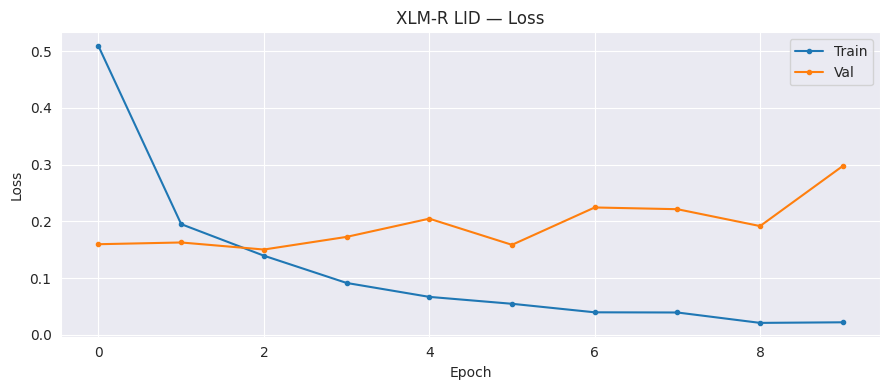

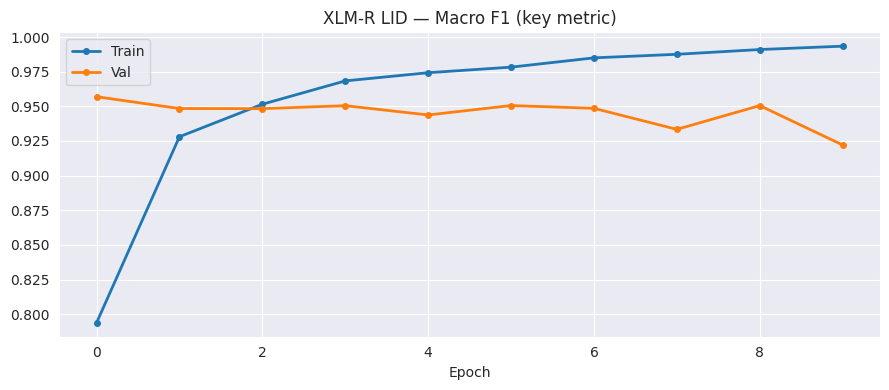

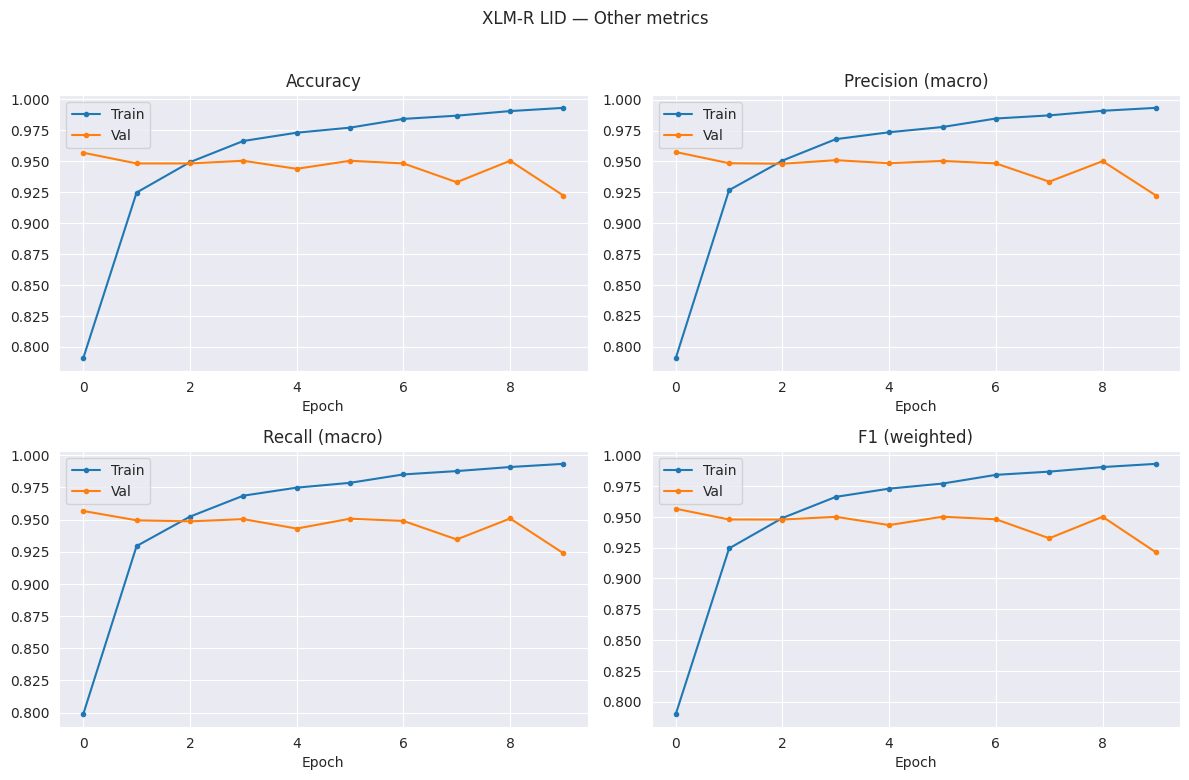

100%|██████████| 10/10 [07:20<00:00, 44.07s/it]


{'loss': 0.15032493968804678,
 'acc': 0.9567099567099567,
 'f1_macro': 0.956926769061012,
 'f1_weighted': 0.9565455345431049,
 'precision': 0.957675925293322,
 'recall': 0.9567078189300412}

In [ ]:
best_val_results = fit(model, train_ldr, val_ldr, optim, epochs=10, loss_fn=loss_fn, title='XLM-R LID', name='xlm-r_v1')
best_val_results

### Evaluation

In [ ]:
model.load_state_dict(torch.load(r'models\xlm-roberta\xlm-r_v1.pt', map_location=device, weights_only=True))
best_test_results1 = test(model, test_ldr, loss_fn, device)

test: 100%|██████████| 15/15 [00:01<00:00,  7.73it/s]

best_test_f1_macro: 0.9592253043915449
best_test_loss: 0.129002366711696
best_test_acc: 0.9587852494577006
best_test_f1: 0.9587946380751968
best_test_prec: 0.9593194686110419
best_test_rec: 0.959144237405107

Confusion matrix (rows=true, cols=pred):
        ru   kz  mixed
ru     148    0      2
kz       0  142      8
mixed    2    7    152


## 6.12.3 V2

### Training

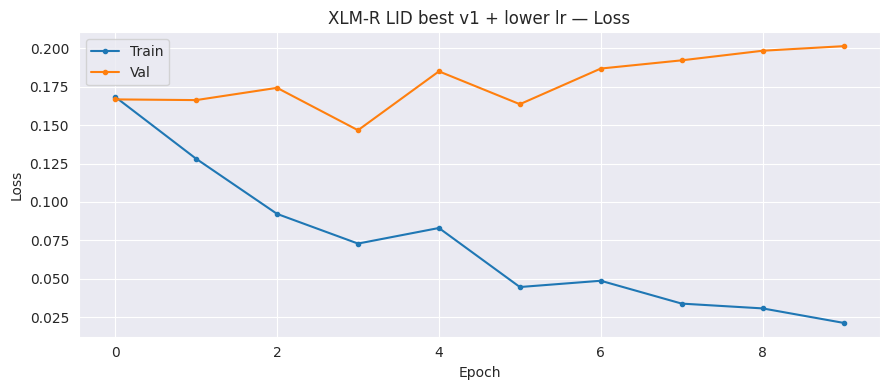

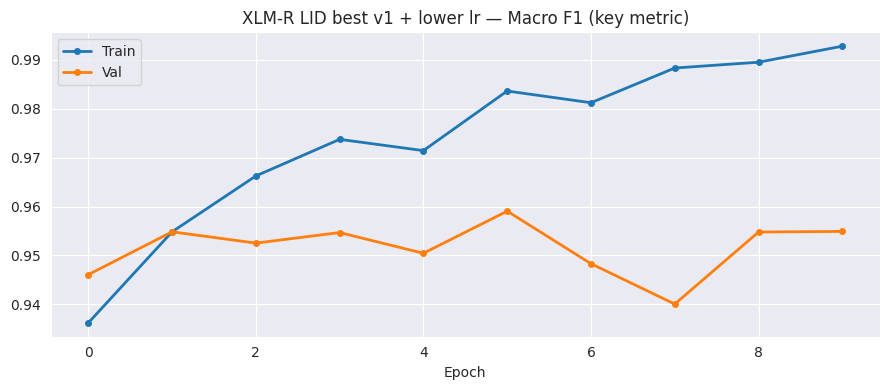

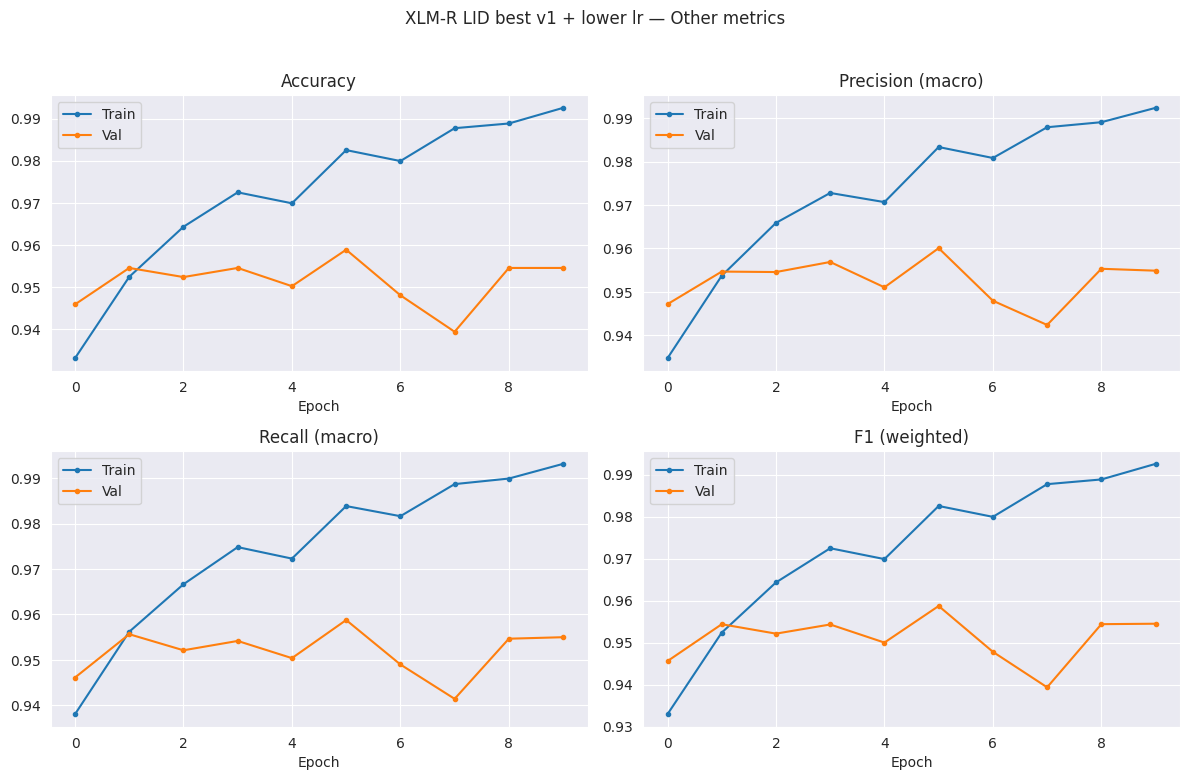

100%|██████████| 10/10 [07:31<00:00, 45.18s/it]


{'loss': 0.14663702845573426,
 'acc': 0.9588744588744589,
 'f1_macro': 0.9590627310939386,
 'f1_weighted': 0.9587092717266816,
 'precision': 0.9600674220763175,
 'recall': 0.9587654320987654}

In [ ]:
model = model.to(device)

optim = AdamW(model.parameters(), lr=1e-5, weight_decay=0.065)

best_val_results = fit(model, train_ldr, val_ldr, optim, epochs=10, loss_fn=loss_fn, title='XLM-R LID best v1 + lower lr', name='xlm-r_v2')
best_val_results

### Evaluation

In [ ]:
model.load_state_dict(torch.load(r'models\xlm-roberta\xlm-r_v2.pt', map_location=device, weights_only=True))
best_test_results2 = test(model, test_ldr, loss_fn, device)

test: 100%|██████████| 15/15 [00:01<00:00,  7.67it/s]

best_test_f1_macro: 0.9655693922260359
best_test_loss: 0.09076739009469748
best_test_acc: 0.96529284164859
best_test_f1: 0.9652052985917233
best_test_prec: 0.9655373745762761
best_test_rec: 0.9656590752242926

Confusion matrix (rows=true, cols=pred):
        ru   kz  mixed
ru     150    0      0
kz       0  142      8
mixed    2    6    153


## 6.12.4 Models comparison and Training conclusion

### Comparison

In [ ]:
metric_keys = ['loss', 'acc', 'f1_macro', 'f1_weighted', 'precision', 'recall']
results_df = pd.DataFrame([best_test_results1, best_test_results2], index=['v1', 'v2'])[metric_keys]
print(f'confussion matrix v1: \n{best_test_results1['confusion_matrix']} \n')
print(f'confussion matrix v2: \n{best_test_results2['confusion_matrix']}')


confussion matrix v1: 
        ru   kz  mixed
ru     148    0      2
kz       0  142      8
mixed    2    7    152 

confussion matrix v2: 
        ru   kz  mixed
ru     150    0      0
kz       0  142      8
mixed    2    6    153


### Conclusion

# 7. Mixed search with fine-tuned model

New dataset class for language identification and run function 

In [ ]:
class MixedSearchingDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=256):
        self.df = df
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.texts = df['text'].astype(str).values 

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        
        enc = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        
        item = {key: val.squeeze(0) for key, val in enc.items()}
        return item


def search_mixed(model, dataset_ldr, device=device):
    all_preds = []

    with torch.no_grad():
        for batch in tqdm(dataset_ldr):
            batch = {key: value.to(device) for key, value in batch.items()}
            logits = model(**batch).logits
            preds = torch.argmax(logits, dim=1) 

            all_preds.extend(preds.cpu().numpy())

    return all_preds

Language identification on `kaspi-telegram_dataset.csv`

In [ ]:
kas_tel_df = pd.read_csv(r'data\processed\kaspi-telegram_dataset.csv')
dataset = MixedSearchingDataset(kas_tel_df, tokenizer)
dataset_ldr = DataLoader(dataset, batch_size=64)
model.load_state_dict(torch.load(r'models\xlm-roberta\lid\xlm-r_v2.pt', map_location=device, weights_only=True))


kas_tel_df['language'] = search_mixed(model, dataset_ldr)

100%|██████████| 3979/3979 [1:07:02<00:00,  1.01s/it]


Result

In [ ]:
id2label={0: "ru", 1: "kz", 2: "mixed"}
kas_tel_df['language'] = kas_tel_df['language'].map(id2label)
kas_tel_df['language'].value_counts()

language
ru       226371
kz        20344
mixed      7937
Name: count, dtype: int64

Saving the whole and only mixed dataset

In [ ]:
kas_tel_df.to_csv(r'data\processedkaspi-telegram_dataset_v2', index=False)

In [19]:
kas_tel_df = pd.read_csv(r'data\processed\kaspi-telegram_dataset_v2.csv')
kas_tel_mixed = kas_tel_df[kas_tel_df['language'] == 'mixed']
kas_tel_mixed.to_csv(r'data\processed\kas_tel_mixed.csv')

During tone labeling it was noticed that negative samples meet rarely. To address the ishue I decided to collect 1-2 star 2gis reviews
# 8. Collecting Data (3). 2GIS
## 8.1 Negatives
### Wave 1

In [2]:
from collect_2gis_reviews import main

main([
    '--out', 'data/raw/2gis_reviews_negative.csv',
    '--cities', 'shymkent', 'atyrau', 'almaty',
    '--categories',
        'шаурма', 'шашлычная', 'жкх', 'управляющая компания', 'рынок',
        'стоматология', 'автосервис', 'доставка еды', 'микрозаймы',
    '--max-firms', '100',
    '--max-reviews-per-firm', '200',
    '--firm-timeout', '90',
    '--sleep', '1.0',
])

[search] shymkent / шаурма
  firms found: 100
  [1/100] scanning...
  [1/100] 70000001067320587: +65 neg reviews
  [3/100] 70000001109564326: +13 neg reviews
  [4/100] 70000001100149113: +66 neg reviews
  [6/100] 70000001093454001: +194 neg reviews
  [8/100] 70000001110131369: +7 neg reviews
  [9/100] 70000001032173420: +198 neg reviews
  [11/100] 70000001103629540: +29 neg reviews
  [13/100] 70000001109900368: +53 neg reviews
  [15/100] 70000001064220926: +50 neg reviews
  [17/100] 70000001087571500: +182 neg reviews
  [18/100] 70000001098545235: +71 neg reviews
  [19/100] 70000001082528444: +4 neg reviews
  [22/100] 70000001017201552: +187 neg reviews
  [25/100] scanning...
  [25/100] 70000001018642389: +18 neg reviews
  [32/100] 70000001017883849: +34 neg reviews
  [39/100] 70000001020957398: +86 neg reviews
  [44/100] 70000001046985556: +19 neg reviews
  [48/100] 70000001033287644: +15 neg reviews
  [50/100] scanning...
  [50/100] 70000001036402490: +7 neg reviews
  saved 1298 rows

[ReviewRow(text='Қызмет дұрыс көрсетте алмайт оффтар нашар не бар не жок екенін блмиттт', rating=1, city='shymkent', category='шаурма', place_id='70000001067320587', place_name='', review_id='247695983', date_created='2026-06-05T06:01:43.972554+07:00', source='2gis'),
 ReviewRow(text='Дұрыс қызмет көрсету білмит и дорекі қыз екен кассада заказ алып отқан қыз', rating=1, city='shymkent', category='шаурма', place_id='70000001067320587', place_name='', review_id='247695967', date_created='2026-06-05T06:01:31.393506+07:00', source='2gis'),
 ReviewRow(text='Заведение ужасное тамак еты куйып кеткен лаваш берди', rating=1, city='shymkent', category='шаурма', place_id='70000001067320587', place_name='', review_id='247053252', date_created='2026-06-02T22:38:09.274391+07:00', source='2gis'),
 ReviewRow(text='Жай қимылдайды', rating=1, city='shymkent', category='шаурма', place_id='70000001067320587', place_name='', review_id='245988042', date_created='2026-05-30T00:48:27.821786+07:00', source='2g

### Wave 2

In [ ]:
main([
    '--resume',  
    '--out', 'data/raw/2gis_reviews_negative.csv',
    '--cities',
        'astana', 'karaganda', 'aktobe',
        'turkestan', 'taraz', 'kyzylorda', 'aktau',
    '--categories',

        'жкх', 'управляющая компания', 'застройщик',
        'рынок', 'микрозаймы', 'ломбард',
        'доставка еды', 'такси',
        'автосервис', 'шиномонтаж', 'автомойка',
        'стоматология', 'поликлиника', 'аптеки',
        'шаурма', 'шашлычная', 'столовая',
        'салоны красоты', 'парикмахерская',
        'школы', 'детские сады',
    '--max-firms', '80',
    '--max-reviews-per-firm', '150',
    '--firm-timeout', '90',
    '--sleep', '1.0',
])

resume: 10363 texts already in data/raw/2gis_reviews_negative.csv
[search] astana / жкх
  firms found: 80
  [1/80] scanning...
  [2/80] 70000001110143629: +4 neg reviews
  [3/80] 70000001089635057: +1 neg reviews
  [4/80] 70000001020511792: +1 neg reviews
  [5/80] 70000001018131606: +149 neg reviews
  [6/80] 70000001027493656: +1 neg reviews
  [7/80] 70000001068709327: +6 neg reviews
  [8/80] 70000001027469302: +16 neg reviews
  [9/80] 70000001062415418: +1 neg reviews
  [10/80] 70000001034405057: +1 neg reviews
  [11/80] 70000001018101899: +1 neg reviews
  [12/80] 70000001038172721: +60 neg reviews
  [25/80] scanning...
  [44/80] 70000001036402490: +1 neg reviews
  [50/80] scanning...
  saved 242 rows → data/raw/2gis_reviews_negative.csv (every 50 firms, ~242 new this run)
  [75/80] scanning...
  [75/80] 70000001019815850: +1 neg reviews
  saved 1 rows → data/raw/2gis_reviews_negative.csv (end of category, ~243 new this run)
[search] astana / управляющая компания
  firms found: 80
  [

[ReviewRow(text='Соприкасался с несколькими управляющиму компаниями в разных городах, но это самая слабая, не понятно за что платишь, банально лампочки не могут нормально поменять, о другом даже можно не говорить', rating=1, city='astana', category='жкх', place_id='70000001110143629', place_name='', review_id='239520829', date_created='2026-04-30T21:51:22.70037+07:00', source='2gis'),
 ReviewRow(text='Осень плохое сервис обслуживание бухгалтера не компетентное за месяц при долге 3200 начисляет пеню на 1400 будьте осторожны', rating=1, city='astana', category='жкх', place_id='70000001110143629', place_name='', review_id='237223826', date_created='2026-04-20T14:14:38.258862+07:00', source='2gis'),
 ReviewRow(text='Всем добрый день ! Кинули наш ЖК Алтын дала 31 декабря 25г, уведомление от 27-28 декабря 25г. кто так вообще поступает??? Непрофессионально! Всегда уведомление за 1 месяц должно хотя бы. Не помыли подъезды, ни лестничные проходы, от многих ЖК наслышаны что так работает недоброс

Results

In [15]:
negatives_2gis = pd.read_csv('data/raw/2gis_reviews_negative.csv')
print(f'total rows: {len(negatives_2gis)}\n')
print(negatives_2gis['city'].value_counts(), '\n')
print(negatives_2gis['rating'].value_counts())

total rows: 41972

city
astana       11497
karaganda     5135
aktobe        4925
almaty        4233
shymkent      3698
aktau         3697
taraz         2706
atyrau        2432
kyzylorda     2068
turkestan     1581
Name: count, dtype: int64 

rating
1    37417
2     4555
Name: count, dtype: int64


Results after cheap clean

In [16]:
negatives_2gis = cheap_clean(negatives_2gis)
print(f'total rows after cheap cleaning: {len(negatives_2gis)}\n')
print(negatives_2gis['city'].value_counts(), '\n')
print(negatives_2gis['rating'].value_counts())

total rows after cheap cleaning: 29479

city
astana       7734
karaganda    3564
aktobe       3478
almaty       2829
shymkent     2743
aktau        2731
taraz        1972
atyrau       1720
kyzylorda    1533
turkestan    1175
Name: count, dtype: int64 

rating
1    26390
2     3089
Name: count, dtype: int64


Language identification

In [ ]:
dataset = MixedSearchingDataset(negatives_2gis, tokenizer)
dataset_ldr = DataLoader(dataset, batch_size=64)
model.load_state_dict(torch.load(r'models\xlm-roberta\xlm-r_v2.pt', map_location=device, weights_only=True))

negatives_2gis['language'] = search_mixed(model, dataset_ldr)

100%|██████████| 461/461 [06:13<00:00,  1.23it/s]


In [ ]:
id2label={0: "ru", 1: "kz", 2: "mixed"}

negatives_2gis['language'] = negatives_2gis['language'].map(id2label)
negatives_2gis['language'].value_counts()

language
ru       20883
mixed     4335
kz        4261
Name: count, dtype: int64

Saving the whole and only mixed dataset

In [ ]:
negatives_2gis.to_csv(r'data\processed\2gis_reviews_negative.csv', index=False)
negatives_2gis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29479 entries, 0 to 29478
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   text          29479 non-null  object 
 1   rating        29479 non-null  int64  
 2   city          29479 non-null  object 
 3   category      29479 non-null  object 
 4   place_id      29479 non-null  int64  
 5   place_name    0 non-null      float64
 6   review_id     29479 non-null  int64  
 7   date_created  29479 non-null  object 
 8   source        29479 non-null  object 
 9   language      29479 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 2.2+ MB


In [8]:
negatives_2gis = pd.read_csv(r'data\processed\2gis_reviews_negative.csv')
print(negatives_2gis.info())


negatives_2gis_mixed = negatives_2gis[negatives_2gis['language'] == 'mixed']

negatives_2gis.to_csv(r'data\processed\2gis_reviews_negative_mixed.csv')
negatives_2gis_mixed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29479 entries, 0 to 29478
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   text          29479 non-null  object 
 1   rating        29479 non-null  int64  
 2   city          29479 non-null  object 
 3   category      29479 non-null  object 
 4   place_id      29479 non-null  int64  
 5   place_name    0 non-null      float64
 6   review_id     29479 non-null  int64  
 7   date_created  29479 non-null  object 
 8   source        29479 non-null  object 
 9   language      29479 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 2.2+ MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 4335 entries, 0 to 29475
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   text          4335 non-null   object 
 1   rating        4335 non-null   int64  
 2   city          4335 non-null 

Creating `main.csv` dataset. All the data collected during the project will be included

In [35]:
main_dataset = pd.concat([kas_tel_df, negatives_2gis])
main_dataset = main_dataset[['text', 'language', 'label']]
main_dataset.info()
print('\n', main_dataset['language'].value_counts())

main_dataset.to_csv(r'data\processed\main.csv')

<class 'pandas.core.frame.DataFrame'>
Index: 284131 entries, 0 to 29478
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   text      284131 non-null  object 
 1   language  284131 non-null  object 
 2   label     0 non-null       float64
dtypes: float64(1), object(2)
memory usage: 8.7+ MB

 language
ru       247254
kz        24605
mixed     12272
Name: count, dtype: int64


Creating `main_mixed.csv`. All the identified mixed from `main.csv` will be included

In [36]:
main_mixed = main_dataset[main_dataset['language'] == 'mixed']
main_mixed.to_csv(r'data\processed\main_mixed.csv')

main_mixed['language'].value_counts()

language
mixed    12272
Name: count, dtype: int64

During tone labeling negative rewiews met earlier. Moreover, the majority of found positive samples are mostly from telegram, the minority from kaspi, so there is a domain disbalance. I decided to make a focus on reviews tone classification and collect positive reviews also from 2 gis

## 8.2 Positives
### Wave 1

In [ ]:
from collect_2gis_reviews import main_positive

main_positive(
    resume=True,
    cities=['astana', 'shymkent', 'almaty'],
    categories=['шаурма', 'жкх', 'стоматология', 'доставка еды'],
    max_firms=100,           
    max_reviews_per_firm=200,
)

sentiment=positive ratings=4,5 → data/raw/2gis_reviews_positive.csv
[search] astana / шаурма
  firms found: 100
  [1/100] scanning...
  [1/100] 70000001113725685: +199 high-rated reviews
  [2/100] 70000001039956256: +193 high-rated reviews
  [4/100] 70000001080671032: +194 high-rated reviews
  [6/100] 70000001059993399: +200 high-rated reviews
  [8/100] 70000001035519049: +197 high-rated reviews
  [10/100] 70000001088913151: +163 high-rated reviews
  [12/100] 70000001041625905: +197 high-rated reviews
  [14/100] 70000001040604576: +194 high-rated reviews
  [16/100] 70000001018123678: +193 high-rated reviews
  [17/100] 70000001019630846: +199 high-rated reviews
  [19/100] 70000001090334910: +175 high-rated reviews
  [21/100] 70000001100168273: +197 high-rated reviews
  [23/100] 70000001063303344: +190 high-rated reviews
  [25/100] scanning...
  [26/100] 70000001017201552: +194 high-rated reviews
  [29/100] 70000001018642389: +192 high-rated reviews
  [36/100] 70000001017883849: +180 hig

[ReviewRow(text='Всё было вкусно 🤤 Спасибо за обслуживание! Отдельное спасибо официанту Каракат.', rating=5, city='astana', category='шаурма', place_id='70000001113725685', place_name='', review_id='248659439', date_created='2026-06-09T11:48:09.066535+07:00', source='2gis'),
 ReviewRow(text='Қайырлы таң!өте керемет жаңа шайхана Хадия ашылды,әдемі интерьер,таңғы асқа осында келуге кеңес берем!\nДаяшы Абархан керемет жұмысың жасап ,жақсы көңіл күй сыйлады!', rating=5, city='astana', category='шаурма', place_id='70000001113725685', place_name='', review_id='248659673', date_created='2026-06-09T11:49:37.76431+07:00', source='2gis'),
 ReviewRow(text='Тамақтары өте дәмді,қызмет көрсету сапасы өте жоғары деңгейде. Асланға үлкен рахмет,жақсы қарсы алды😍😍👍👍👍', rating=5, city='astana', category='шаурма', place_id='70000001113725685', place_name='', review_id='248594505', date_created='2026-06-09T00:34:22.778+07:00', source='2gis'),
 ReviewRow(text='Маған бәрі өте ұнады! Қызмет көрсету сапасы жоғ

### Wave 2

In [39]:
from collect_2gis_reviews import main_positive

main_positive(
    resume=True,
    cities=['karaganda', 'aktobe', 'aktau', 'semey'],
    categories=[
        'доставка еды', 'кафе',
        'стоматология', 'аптеки', 'автосервис',
        'салоны красоты', 'супермаркеты', 'торговый центр',
    ],
    max_firms=80,
    max_reviews_per_firm=150,
)

sentiment=positive ratings=4,5 → data/raw/2gis_reviews_positive.csv
resume: 18962 texts already in data/raw/2gis_reviews_positive.csv
[search] karaganda / доставка еды
  firms found: 80
  [1/80] scanning...
  [1/80] 70000001018770584: +141 high-rated reviews
  [3/80] 70000001110243935: +123 high-rated reviews
  [4/80] 70000001112705298: +44 high-rated reviews
  [6/80] 70000001111848846: +24 high-rated reviews
  [7/80] 70000001021344953: +143 high-rated reviews
  [9/80] 70000001026740242: +137 high-rated reviews
  [11/80] 70000001111859514: +32 high-rated reviews
  [12/80] 70000001075300594: +146 high-rated reviews
  [13/80] 70000001109577633: +140 high-rated reviews
  [14/80] 70000001046054162: +66 high-rated reviews
  [16/80] 70000001037297951: +146 high-rated reviews
  [17/80] 70000001104912818: +143 high-rated reviews
  [25/80] scanning...
  [50/80] scanning...
  saved 1285 rows → data/raw/2gis_reviews_positive.csv (every 50 firms, ~1285 new this run)
  [75/80] scanning...
[search] 

[ReviewRow(text='Доставка вовремя, суши шикарнейшие, свежие, вкусные', rating=5, city='karaganda', category='доставка еды', place_id='70000001018770584', place_name='', review_id='248349468', date_created='2026-06-08T00:13:52.531346+07:00', source='2gis'),
 ReviewRow(text='Очень нравятся именно ваши суши. Отличный сервис доставки', rating=5, city='karaganda', category='доставка еды', place_id='70000001018770584', place_name='', review_id='248311291', date_created='2026-06-07T21:10:08.090069+07:00', source='2gis'),
 ReviewRow(text='Очень вкусные суши, сытные большие свежие, часто заказываю здесь', rating=5, city='karaganda', category='доставка еды', place_id='70000001018770584', place_name='', review_id='247903775', date_created='2026-06-05T23:58:59.680745+07:00', source='2gis'),
 ReviewRow(text='Частенько заказываем здесь роллы и пиццу, всегда вкусно и быстро🤌🏼', rating=5, city='karaganda', category='доставка еды', place_id='70000001018770584', place_name='', review_id='247870692', dat

Result

In [55]:
positives_2gis = pd.read_csv('data/raw/2gis_reviews_positive.csv')
print(f'total rows: {len(positives_2gis)}\n')
print(positives_2gis['city'].value_counts(), '\n')
print(positives_2gis['rating'].value_counts())

total rows: 46865

city
astana       8983
aktobe       7597
aktau        7420
karaganda    6894
semey        5992
almaty       5508
shymkent     4471
Name: count, dtype: int64 

rating
5    44288
4     2577
Name: count, dtype: int64


Result after cheap clean

In [ ]:
positives_2gis = cheap_clean(positives_2gis)
print(f'total rows after cheap cleaning: {len(positives_2gis)}\n')
print(positives_2gis['city'].value_counts(), '\n')
print(positives_2gis['rating'].value_counts())

total rows after cheap cleaning: 35928

city
astana       7062
aktobe       5762
aktau        5472
karaganda    5338
semey        4467
almaty       4362
shymkent     3465
Name: count, dtype: int64 

rating
5    34065
4     1863
Name: count, dtype: int64


Language identification

In [ ]:
dataset = MixedSearchingDataset(positives_2gis, tokenizer)
dataset_ldr = DataLoader(dataset, batch_size=64)
model.load_state_dict(torch.load(r'models\xlm-roberta\lid\xlm-r_v2.pt', map_location=device, weights_only=True))


positives_2gis['language'] = search_mixed(model, dataset_ldr)

100%|██████████| 562/562 [07:59<00:00,  1.17it/s]


In [43]:
id2label={0: "ru", 1: "kz", 2: "mixed"}

positives_2gis['language'] = positives_2gis['language'].map(id2label)
positives_2gis['language'].value_counts()

language
ru       26219
kz        6727
mixed     2982
Name: count, dtype: int64

Saving the whole and only mixed dataset

In [16]:
positives_2gis.to_csv(r'data\processed\2gis_reviews_positive.csv', index=False)


In [15]:
positives_2gis = pd.read_csv(r'data\processed\2gis_reviews_positive.csv')
positives_2gis_mixed = positives_2gis[positives_2gis['language'] == 'mixed']

positives_2gis_mixed.to_csv(r'data\processed\2gis_reviews_positive_mixed.csv', index=False)

Adding positives to `main.csv`

In [47]:
main_dataset = pd.concat([main_dataset, positives_2gis])
main_dataset = main_dataset[['text', 'language', 'label']]
main_dataset.info()
print('\n', main_dataset['language'].value_counts())

main_dataset.to_csv(r'data\processed\main.csv')

<class 'pandas.core.frame.DataFrame'>
Index: 320059 entries, 0 to 35927
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   text      320059 non-null  object 
 1   language  320059 non-null  object 
 2   label     0 non-null       float64
dtypes: float64(1), object(2)
memory usage: 9.8+ MB

 language
ru       273473
kz        31332
mixed     15254
Name: count, dtype: int64


Updating `main_mixed.csv`

In [48]:
main_mixed = main_dataset[main_dataset['language'] == 'mixed']
main_mixed.to_csv(r'data\processed\main_mixed.csv')

main_mixed['language'].value_counts()

language
mixed    15254
Name: count, dtype: int64

Negative samples meet more often. Collect some more positive samples to fix it
### Wave 3

In [ ]:
from collect_2gis_reviews import main_positive

main_positive(
    out='data/raw/2gis_reviews_positive_v2.csv',
    resume=True,
    cities=['atyrau', 'turkestan', 'taraz', 'kyzylorda', 'pavlodar', 'ust_kamenogorsk'],
    categories=[
        'рестораны', 'шашлычная', 'пиццерия', 'поликлиника', 'клиники',
        'барбершоп', 'гостиницы', 'фитнес клубы', 'ремонт телефонов',
    ],
    max_firms=130,
    max_reviews_per_firm=220,
    max_pages_per_firm=10,
    min_text_len=22,
    exclude_csv=[
        r'C:\Users\nadgo\Downloads\tone_labeling.csv',
        'data/raw/2gis_reviews_positive.csv',
        'data/processed/2gis_reviews_positive_mixed.csv',
    ],
    fetch_place_names=True,
)

sentiment=positive ratings=4,5 → data/raw/2gis_reviews_positive_v2.csv
exclude-csv: +52701 texts from 3 file(s) (total skip pool 52701)
[search] atyrau / рестораны
  firms found: 130
  [1/130] scanning...
  [1/130] 70000001058954498: +112 high-rated reviews
  [3/130] 70000001091370310: +55 high-rated reviews
  [4/130] 70000001060804845: +185 high-rated reviews
  [5/130] 70000001035099565: +158 high-rated reviews
  [22/130] 70000001018642389: +19 high-rated reviews
  [25/130] scanning...
  [50/130] scanning...
  saved 529 rows → data/raw/2gis_reviews_positive_v2.csv (every 50 firms, ~529 new this run)
  [75/130] scanning...
  [100/130] scanning...
  [120/130] 70000001044620864: +8 high-rated reviews
  [122/130] 70000001081568939: +2 high-rated reviews
  [123/130] 70000001055200673: +4 high-rated reviews
  [124/130] 70000001006326250: +35 high-rated reviews
  [125/130] scanning...
  [125/130] 70000001032618606: +12 high-rated reviews
  [126/130] 70000001007109534: +13 high-rated reviews


Result

In [3]:
positives_2gis = pd.read_csv('data/raw/2gis_reviews_positive_v2.csv')
print(f'total rows: {len(positives_2gis)}\n')
print(positives_2gis['city'].value_counts(), '\n')
print(positives_2gis['rating'].value_counts())

total rows: 13417

city
atyrau       3890
taraz        3488
pavlodar     2981
turkestan    2075
kyzylorda     983
Name: count, dtype: int64 

rating
5    12593
4      824
Name: count, dtype: int64


Result after cheap clean

In [6]:
positives_2gis = cheap_clean(positives_2gis)
print(f'total rows after cheap cleaning: {len(positives_2gis)}\n')
print(positives_2gis['city'].value_counts(), '\n')
print(positives_2gis['rating'].value_counts())

total rows after cheap cleaning: 11409

city
atyrau       3246
taraz        3004
pavlodar     2562
turkestan    1763
kyzylorda     834
Name: count, dtype: int64 

rating
5    10724
4      685
Name: count, dtype: int64


Language identification

In [ ]:
dataset = MixedSearchingDataset(positives_2gis, tokenizer)
dataset_ldr = DataLoader(dataset, batch_size=64)
model.load_state_dict(torch.load(r'models\xlm-roberta\xlm-r_v2.pt', map_location=device, weights_only=True))


positives_2gis['language'] = search_mixed(model, dataset_ldr)

100%|██████████| 179/179 [02:31<00:00,  1.18it/s]


In [ ]:
id2label={0: "ru", 1: "kz", 2: "mixed"}

positives_2gis['language'] = positives_2gis['language'].map(id2label)
positives_2gis['language'].value_counts()

language
ru       7936
kz       2363
mixed    1110
Name: count, dtype: int64

Saving the whole and only mixed dataset

In [ ]:
positives_2gis.to_csv(r'data\processed\2gis_reviews_positive_v2.csv', index=False)
positives_2gis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35928 entries, 0 to 35927
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   text          35928 non-null  object 
 1   rating        35928 non-null  int64  
 2   city          35928 non-null  object 
 3   category      35928 non-null  object 
 4   place_id      35928 non-null  int64  
 5   place_name    0 non-null      float64
 6   review_id     35928 non-null  int64  
 7   date_created  35928 non-null  object 
 8   source        35928 non-null  object 
 9   language      35928 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 2.7+ MB


In [14]:
positives_2gis = pd.read_csv(r'data\processed\2gis_reviews_positive_v2.csv')
positives_2gis_mixed = positives_2gis[positives_2gis['language'] == 'mixed']

positives_2gis_mixed.to_csv(r'data\processed\2gis_reviews_positive_mixed_v2.csv', index=False)
positives_2gis_mixed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2982 entries, 15 to 35924
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   text          2982 non-null   object 
 1   rating        2982 non-null   int64  
 2   city          2982 non-null   object 
 3   category      2982 non-null   object 
 4   place_id      2982 non-null   int64  
 5   place_name    0 non-null      float64
 6   review_id     2982 non-null   int64  
 7   date_created  2982 non-null   object 
 8   source        2982 non-null   object 
 9   language      2982 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 256.3+ KB


Adding positives to `main.csv` and updating `main_mixed.csv`

In [9]:
main_dataset = pd.concat([main_dataset, positives_2gis])
main_dataset = main_dataset[['text', 'language', 'label']]
main_dataset.info()
print('\n', main_dataset['language'].value_counts())

main_dataset.to_csv(r'data\processed\main.csv')

main_mixed = main_dataset[main_dataset['language'] == 'mixed']
main_mixed.to_csv(r'data\processed\main_mixed.csv')

<class 'pandas.core.frame.DataFrame'>
Index: 331468 entries, 0 to 11408
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   text      331468 non-null  object 
 1   language  331468 non-null  object 
 2   label     0 non-null       float64
dtypes: float64(1), object(2)
memory usage: 10.1+ MB

 language
ru       281409
kz        33695
mixed     16364
Name: count, dtype: int64


## 8.3 Tone dataset overview (gold + synthetic)

> **Note:** This section is an overview prepared by **Cursor AI** following the KazNLP project audit.
### Pipeline (as in `main.ipynb`)

| Step | Where | Artifact |
|------|-------|----------|
| 1 | **8** — collect 2GIS negative/positive, LID via XLM-R (`xlm-r_v2.pt`) | `2gis_reviews_negative.csv`, `2gis_reviews_positive.csv` |
| 2 | **8.1 and 8.2** — filter `language == mixed` | `2gis_reviews_negative_mixed.csv` (4335), `2gis_reviews_positive_mixed.csv` (2982); plus overlap with `main_mixed.csv` (~15k mixed from Kaspi/TG+2GIS) |
| 3 | **Outside notebook** — `python run_labeler.py` (tone mode): batch labeling via Gemini/Composer + manual fixes | `label_source`: `llm_composer` (3312) + `manual` (217) |
| 4 | pos/neg balance, manual audit (cross-check with 2GIS rating, fix inversions) | **`tone_mixed_balanced_audited.csv`** — 3529 gold |
| 5 | 25% synthetic supplement vs gold | `scripts/generate_tone_synthetic.py` → `data/processed/synthetic_tone/tone_synth_batch_*.csv` (882) |
| 6 | Merge + QC + dedup | `scripts/merge_tone_synthetic.py` → **`tone_train_mixed.csv`** — 4411 |

---

### Source files (current)

| File | Rows | Description |
|------|-----:|-------------|
| `data/processed/tone_mixed_balanced_audited.csv` | 3529 | Gold: mixed 2GIS reviews (+ part of the shared mixed pool), labels `positive` / `negative` |
| `data/processed/synthetic_tone/tone_synth_batch_*.csv` | 882 | Synthetic (~25% of gold) |
| **`data/processed/tone_train_mixed.csv`** | **4411** | Final train = gold + synth after QC and dedup |

**Gold composition:** 3312 rows with `label_source=llm_composer` (`language=mixed`) + 217 manual (`label_source=manual`). Balance: 1771 pos / 1758 neg.

**Train composition:** same 3529 gold + 882 synthetic (`label_source=synthetic`) → 2207 pos / 2204 neg (~20% synthetic in merged set).

---

### Issues in the original (gold) dataset

1. **Labeling errors (critical, rare).** Label inversions vs meaning and the original 2GIS rating. Example: pure praise with 5★ labeled `negative`, a scathing review with 1★ labeled `positive`. **2 rows** found and fixed during audit; at scale expect ~0.05–0.1% of such cases.

2. **Mixed tone without a clear dominant (~5–8%).** A review praises and criticizes at once (*"service жақсы, kitchen онша емес"*). For a binary classifier this is noise: the label is formally valid but debatable for humans.

3. **Weak code-switch (~13%).** Text is almost monolingual with 1–2 loanwords (*"Очень вкусно поели, сытно"*). For "tone of mixed utterances" the model sees little real language switching — not critical, but worth tracking in error analysis.

4. **Length bias.** Negative averages ~138 characters, positive ~95. Short positive vs long negative risks learning length instead of sentiment.

5. **Domain gaps.** Gold has little finance, housing, fitness; lots of food/restaurants. The model may overfit to the restaurant domain.

6. **Realistic noise (not a bug).** Typos, CAPS, profanity, fragments — normal for 2GIS; do not strip.

---

### Mitigations (what the project did)

| Issue | Mitigation |
|-------|------------|
| Label errors | Manual audit + 2GIS rating cross-check; fixes in `tone_mixed_balanced_audited.csv` |
| Weak mixed / domains / length | **~25% synthetic vs gold** — 8 targeted batches (`scripts/generate_tone_synthetic.py`) |
| Gold↔synth duplicates | `scripts/merge_tone_synthetic.py` — `normalize_text` + dedup against gold |
| QC (pure RU/KZ, weak bilingual) | `scripts/text_heuristics.py` + `scripts/merge_synthetic.qc_row` at merge |
| Label contamination in synth | `label_contamination()`, salt only with neutral context (city/time/price) |
| Source transparency | `label_source` column: `llm_composer` / `manual` / `synthetic` |

**Regenerate synthetic data and merge:**

```bash
python scripts/generate_tone_synthetic.py
python scripts/merge_tone_synthetic.py

# 9. Tone classificator training
*fine-tuning

Due to synthetic data in the dataset, once again `weight` column has to be added

In [32]:
gold_df = pd.read_csv(r'data\processed\tone_mixed_balanced_audited.csv')
gold_df = cheap_clean(gold_df)

gold_df['weight'] = 3.0
gold_df = gold_df[['text', 'label', 'weight']]
gold_df['label'].value_counts()

label
negative    1754
positive    1749
Name: count, dtype: int64

In [33]:
synthetic_df = pd.read_csv(r'data\processed\tone_synthetic.csv')
synthetic_df = cheap_clean(synthetic_df)

synthetic_df['weight'] = 1.0
synthetic_df = synthetic_df[['text', 'label', 'weight']]
synthetic_df['label'].value_counts()

label
negative    446
positive    436
Name: count, dtype: int64

## 9.1 Train/test/val splitting
Only gold at test and val because it creates real conditions for evaluation

In [36]:
label2id = {'negative': 0,
            'positive': 1}


train_gold, temp_gold = train_test_split(gold_df,
                              test_size=0.30, # 30% is test_df + val_df now
                              stratify=gold_df['label'],
                              random_state=42)

test_df, val_df = train_test_split(temp_gold,
                             test_size=0.5, # half of 30%, 15% for each
                             stratify=temp_gold['label'],
                             random_state=42)

# merging
train_df = pd.concat([train_gold, synthetic_df], ignore_index=True)

train_df['label_id'] = train_df['label'].map(label2id)
test_df['label_id'] = test_df['label'].map(label2id)
val_df['label_id'] = val_df['label'].map(label2id)

train_df.to_csv(r'data\training\tone\v1\train.csv', index=False)
test_df.to_csv(r'data\training\tone\v1\test.csv', index=False)
val_df.to_csv(r'data\training\tone\v1\val.csv', index=False)

print(f'train_df: {len(train_df)}')
print(f'test_df: {len(test_df)}')
print(f'val_df: {len(val_df)}')

train_df: 3334
test_df: 525
val_df: 526


In [37]:
f = pd.read_csv(r'data\training\tone\v1\train.csv')
f

,text,label,weight,label_id
0,Жұмысшылар шаршаса демалдырыңдар! без лука дес...,negative,3.0,0
1,Ерасыл мен Айымға көп көп рахмеет\nБарлығы мен...,positive,3.0,1
2,Оте нашар келмей ак койын\nОдним словом горох,negative,3.0,0
3,"Ассалаумагалейкум,донер оте дамди болып шыгыпт...",positive,3.0,1
4,Поликлиникадағы Шынар Жиенғалиқызы акушерка өт...,positive,3.0,1
...,...,...,...,...
3329,Ценники не совпадают с кассой. Баға кассада ба...,negative,1.0,0
3330,"Продукты просроченные попались. Кезек ұзақ, ка...",negative,1.0,0
3331,"Тренажёры сломаны, никто не чинит. Тренажерлер...",negative,1.0,0
3332,"Тренажёры сломаны, никто не чинит. Жаттықтыруш...",negative,1.0,0


## 9.2 Dataloaders
*and datasets

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')

train = LidDataset(train_df, tokenizer)
test = LidDataset(test_df, tokenizer)
val = LidDataset(val_df, tokenizer)

collator = WeightedCollator(tokenizer=tokenizer)

train_ldr = DataLoader(train, 16, True, collate_fn=collator)
test_ldr = DataLoader(test, 32, False, collate_fn=collator)
val_ldr = DataLoader(val, 32, False, collate_fn=collator)

## 9.3 Model and Optimizer

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    'xlm-roberta-base',
    num_labels=2,
    id2label={0: 'negative', 1: 'positive'},
    label2id={'negative': 0, 'positive': 1}).to(device)

optim = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

## 9.4 Test function for tone classification

In [ ]:
def test_tone(model, test_ldr, loss_fn, device):
    model.eval()
    n_batches = len(test_ldr)
    n_samples = len(test_ldr.dataset)

    total_loss = total_correct = 0
    all_y_true, all_y_pred = [], []

    with torch.no_grad():
        for batch in tqdm(test_ldr, desc='test_tone'):
            batch.pop('weight', None)
            y = batch.pop('labels').to(device)
            batch = {k: v.to(device) for k, v in batch.items()}

            pred = model(**batch).logits
            loss = loss_fn(pred, y).mean()

            y_pred = pred.argmax(dim=1)
            total_loss += loss.item()
            total_correct += (y_pred == y).sum().item()

            all_y_true.append(y.detach().cpu().numpy())
            all_y_pred.append(y_pred.detach().cpu().numpy())

    y_true = np.concatenate(all_y_true)
    y_pred = np.concatenate(all_y_pred)

    test_loss = total_loss / n_batches
    test_acc = total_correct / n_samples
    test_f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    test_f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    test_prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    test_rec = recall_score(y_true, y_pred, average='macro', zero_division=0)

    print(f'test_f1_macro: {test_f1_macro:.4f}')
    print(f'test_loss: {test_loss:.4f}')
    print(f'test_acc: {test_acc:.4f}')
    print(f'test_f1_weighted: {test_f1_weighted:.4f}')
    print(f'test_prec: {test_prec:.4f}')
    print(f'test_rec: {test_rec:.4f}')

    label_names = ['negative', 'positive']
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
    print('\nConfusion matrix (rows=true, cols=pred):')
    print(cm_df)

    return {
        'loss': test_loss,
        'acc': test_acc,
        'f1_macro': test_f1_macro,
        'f1_weighted': test_f1_weighted,
        'precision': test_prec,
        'recall': test_rec,
        'y_true': y_true,
        'y_pred': y_pred,
        'confusion_matrix': cm_df,
    }

## 9.5 V1
### Training

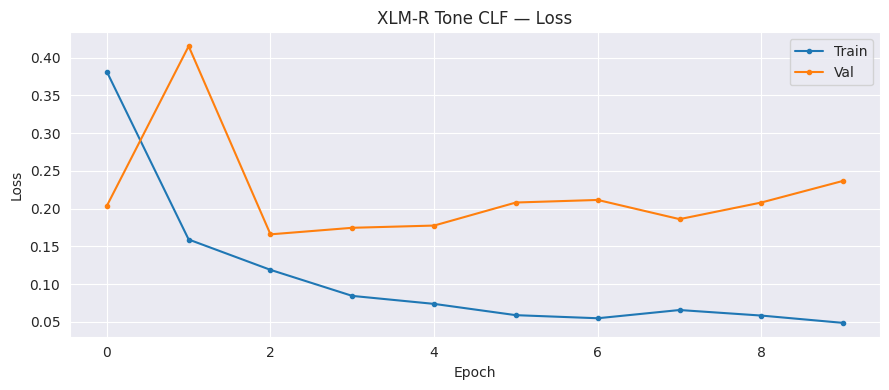

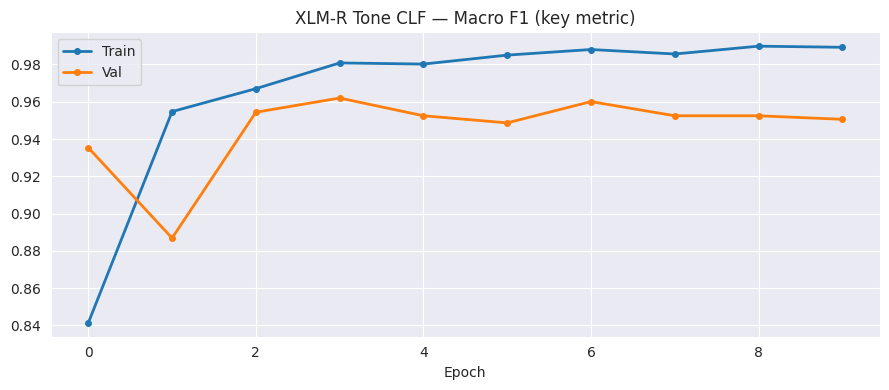

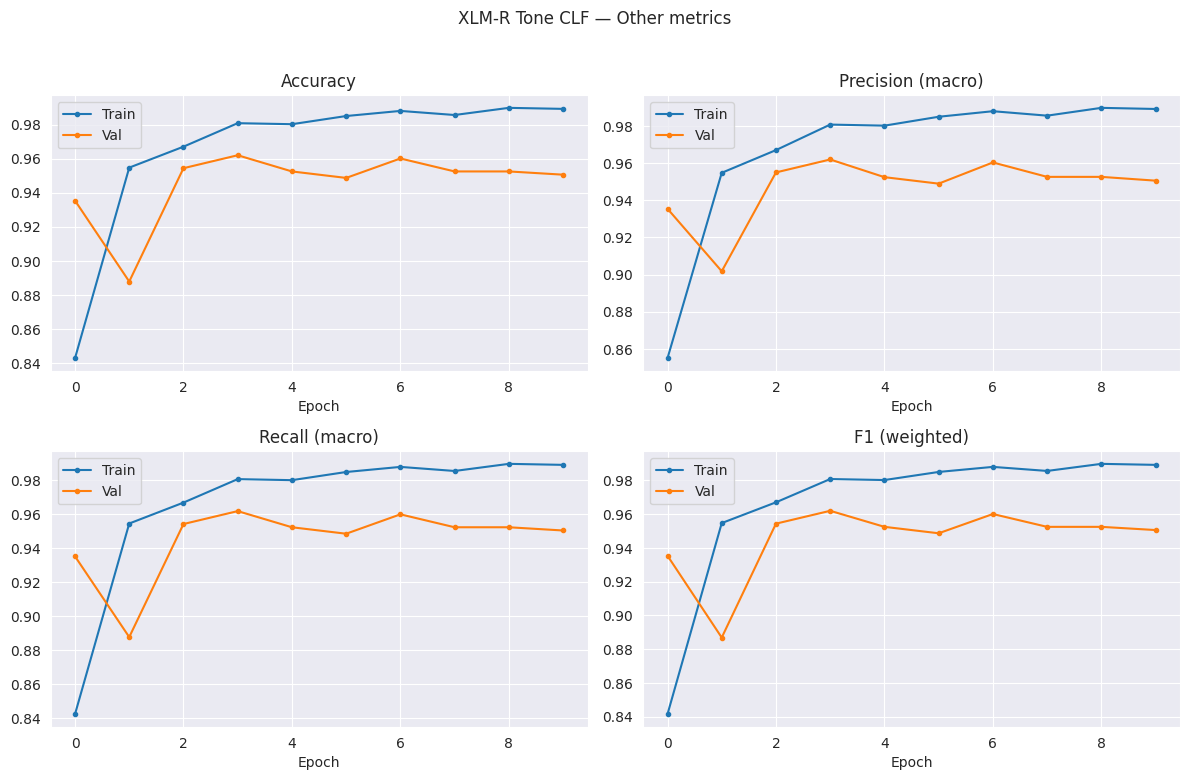

100%|██████████| 10/10 [10:57<00:00, 65.72s/it]


{'loss': 0.16595426705830238,
 'acc': 0.9619771863117871,
 'f1_macro': 0.9619766365949572,
 'f1_weighted': 0.9619766365949572,
 'precision': 0.9620039037085231,
 'recall': 0.9619771863117871}

In [ ]:
best_val_results = fit(model, train_ldr, val_ldr, optim, epochs=10, loss_fn=loss_fn, title='XLM-R Tone CLF', name='xlm-r_v1')
best_val_results

### Evaluation

In [ ]:
model.load_state_dict(torch.load(r'models\xlm-roberta\tone\xlm-r_v1.pt', map_location=device, weights_only=True))
best_test_results1 = test_tone(model, test_ldr, loss_fn, device)

test_tone: 100%|██████████| 17/17 [00:02<00:00,  6.04it/s]

test_f1_macro: 0.9733
test_loss: 0.0910
test_acc: 0.9733
test_f1_weighted: 0.9733
test_prec: 0.9734
test_rec: 0.9733

Confusion matrix (rows=true, cols=pred):
          negative  positive
negative       257         6
positive         8       254


## 9.6 V2

### Training

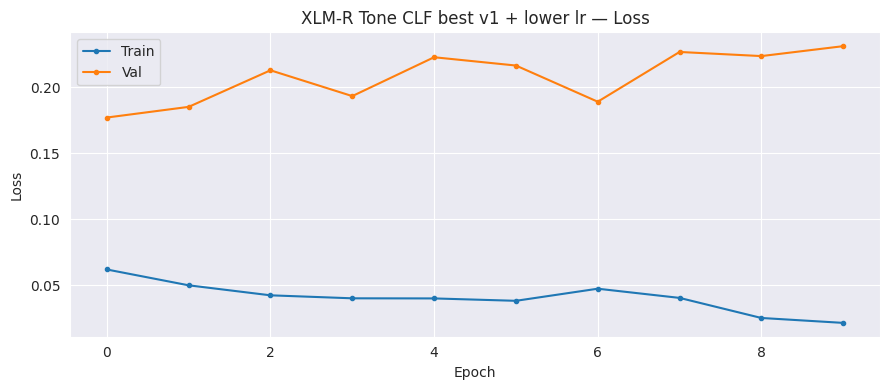

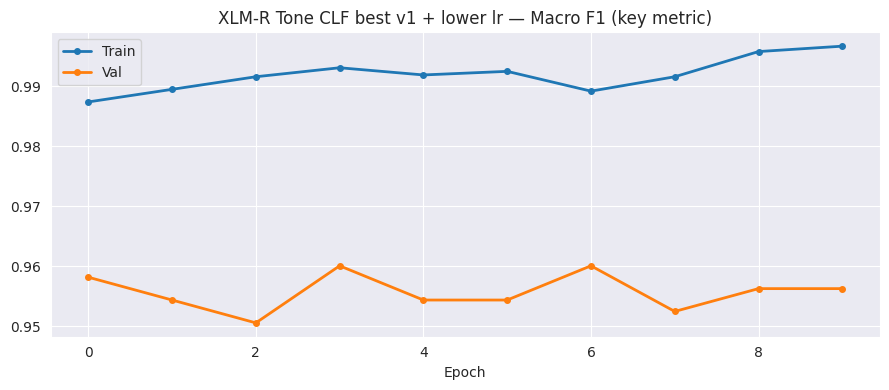

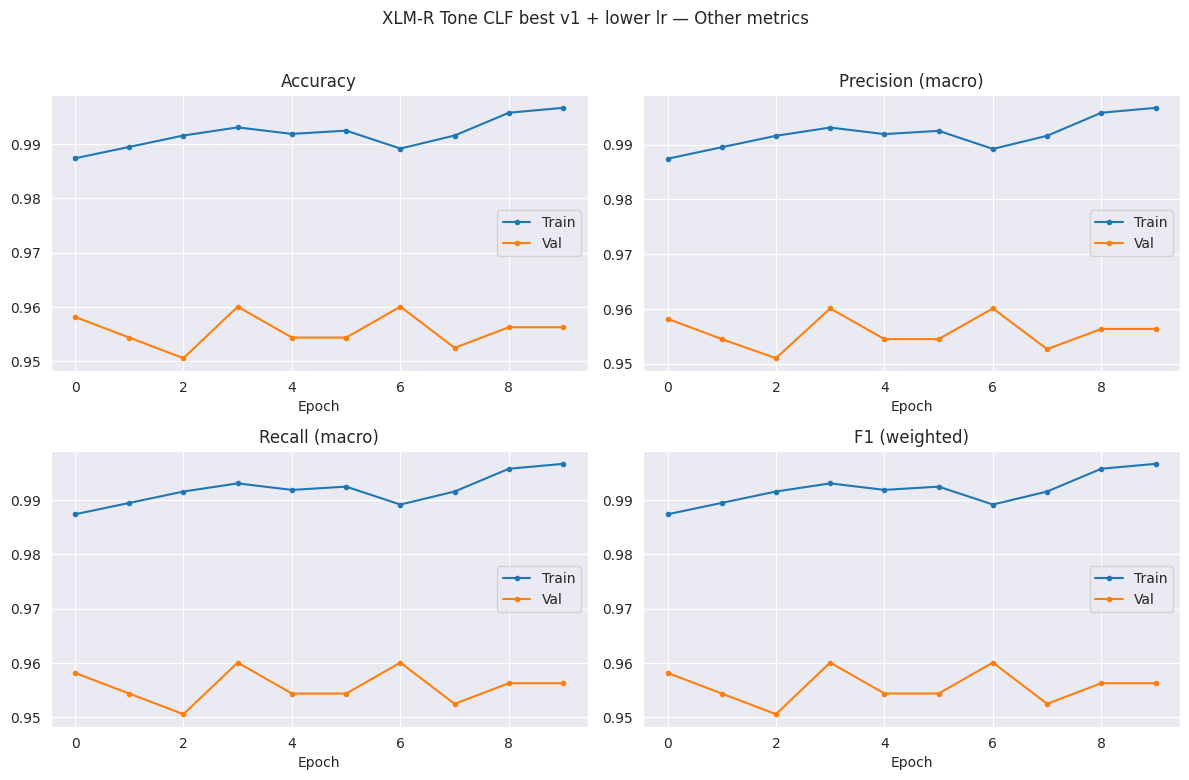

100%|██████████| 10/10 [10:58<00:00, 65.86s/it]


{'loss': 0.17719209857065887,
 'acc': 0.9600760456273765,
 'f1_macro': 0.9600759013282733,
 'f1_weighted': 0.9600759013282733,
 'precision': 0.9600826972010179,
 'recall': 0.9600760456273765}

In [ ]:
model = model.to(device)
model.load_state_dict(torch.load(r'models\xlm-roberta\tone\xlm-r_v1.pt', map_location=device, weights_only=True))

optim = AdamW(model.parameters(), lr=1e-5, weight_decay=0.065)

best_val_results = fit(model, train_ldr, val_ldr, optim, epochs=10, loss_fn=loss_fn, title='XLM-R Tone CLF best v1 + lower lr', name='xlm-r_v2')
best_val_results

### Evaluation

In [ ]:
model.load_state_dict(torch.load(r'models\xlm-roberta\tone\xlm-r_v2.pt', map_location=device, weights_only=True))
best_test_results2 = test_tone(model, test_ldr, loss_fn, device)

test_tone: 100%|██████████| 17/17 [00:02<00:00,  6.33it/s]

test_f1_macro: 0.9619
test_loss: 0.1292
test_acc: 0.9619
test_f1_weighted: 0.9619
test_prec: 0.9619
test_rec: 0.9619

Confusion matrix (rows=true, cols=pred):
          negative  positive
negative       253        10
positive        10       252


## 9.7 Models comparison and Training conclusion

### Comparison

In [ ]:
metric_keys = ['loss', 'acc', 'f1_macro', 'f1_weighted', 'precision', 'recall']
results_df = pd.DataFrame([best_test_results1, best_test_results2], index=['v1', 'v2'])[metric_keys]
print(f'confussion matrix v1: \n{best_test_results1['confusion_matrix']} \n')
print(f'confussion matrix v2: \n{best_test_results2['confusion_matrix']}')


confussion matrix v1: 
          negative  positive
negative       257         6
positive         8       254 

confussion matrix v2: 
          negative  positive
negative       253        10
positive        10       252


### Conclusion

V1 started to overfit but in overall has stunning quality on the test set

Trays of overfitting on V2 are noticable better. It happened because V2 is fine-tuned V1 which had already remembered the train set and started to overdit since the first epoch

In overall, V1 is a little better than V2, so the core model will be V1

# 10. LID models comparison

## 10.1 FastText and Lingua on LID gold test

In [2]:
import numpy as np

_np = np.array

def _array_compat(obj, *args, copy=None, **kwargs):
    if copy is False:
        return np.asarray(obj, *args, **kwargs)
    return _np(obj, *args, copy=copy, **kwargs)

np.array = _array_compat

import fasttext
import pandas as pd
from lingua import Language, LanguageDetectorBuilder
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from tqdm import tqdm

FT_V1 = 'models/fasttext/fasttext_v1.bin'
FT_V2 = 'models/fasttext/fasttext_v2.bin'
GOLD_TEST = 'data/training/filter/v1/test.csv'
LABELS = ['ru', 'kz', 'mixed']

detector = LanguageDetectorBuilder.from_languages(
    Language.KAZAKH,
    Language.RUSSIAN,
).build()
kaz_specific = set('әіңғүұқөһ')


def classify_text(text):
    text = str(text).strip()
    words = text.split()
    if len(words) < 2:
        return 'short'

    kaz_words = rus_words = 0
    for word in words:
        if any(c in kaz_specific for c in word.lower()):
            kaz_words += 1
            continue
        lang = detector.detect_language_of(word)
        if lang == Language.KAZAKH:
            kaz_words += 1
        elif lang == Language.RUSSIAN:
            rus_words += 1

    total = kaz_words + rus_words
    if total == 0:
        return 'unknown'

    kaz_ratio = kaz_words / total
    if kaz_ratio > 0.85:
        return 'kaz'
    if kaz_ratio < 0.15:
        return 'ru'
    return 'mixed'


def classify_text_v2(text):
    text = str(text).strip()
    words = text.split()
    if len(words) < 3:
        return 'short'

    has_kaz_specific = any(c in kaz_specific for c in text.lower())
    kaz_words = rus_words = 0

    for word in words:
        if len(word) < 3:
            continue
        if any(c in kaz_specific for c in word.lower()):
            kaz_words += 1
            continue
        lang = detector.detect_language_of(word)
        if lang == Language.KAZAKH:
            kaz_words += 1
        elif lang == Language.RUSSIAN:
            rus_words += 1

    total = kaz_words + rus_words
    if total == 0:
        return 'unknown'

    kaz_ratio = kaz_words / total
    if has_kaz_specific and rus_words > 0:
        return 'mixed'
    if kaz_ratio > 0.8:
        return 'kaz'
    if kaz_ratio < 0.2:
        return 'ru'
    return 'ru'


def lingua_to_gold(label):
    if label == 'kaz':
        return 'kz'
    if label in LABELS:
        return label
    return 'ru'


def ft_label(model, text, lower=False):
    t = str(text).replace('\n', ' ').strip()
    if lower:
        t = t.lower()
    if not t:
        return 'ru'
    lab = model.predict(t)[0][0].replace('__label__', '')
    return 'kz' if lab == 'kaz' else lab


def mixed_recall_precision(cm):
    tp = int(cm.loc['mixed', 'mixed'])
    recall_mixed = tp / int(cm.loc['mixed'].sum())    # R(mixed): TP / true mixed
    precision_mixed = tp / int(cm['mixed'].sum())     # P(mixed): TP / pred mixed
    return recall_mixed, precision_mixed


def run_eval(y_true, y_pred):
    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=LABELS),
        index=LABELS, columns=LABELS,
    )
    cm.index.name = 'true'
    cm.columns.name = 'pred'
    recall_mixed, precision_mixed = mixed_recall_precision(cm)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, labels=LABELS, average='macro', zero_division=0),
        'recall_mixed': recall_mixed,
        'precision_mixed': precision_mixed,
    }, cm


def run_ft(model, df, lower=False):
    y_true = df['language'].tolist()
    y_pred = [ft_label(model, t, lower) for t in df['text']]
    return run_eval(y_true, y_pred)


def run_lingua(df, fn, name):
    y_true = df['language'].tolist()
    raw = df['text'].progress_apply(fn)
    print(f'{name} raw labels:', raw.value_counts().to_dict())
    y_pred = [lingua_to_gold(x) for x in raw]
    return run_eval(y_true, y_pred)


test_df = pd.read_csv(GOLD_TEST)
print(test_df['language'].value_counts(), '\n')

ft_v1 = fasttext.load_model(FT_V1)
ft_v2 = fasttext.load_model(FT_V2)

ft_m_v1, cm_ft_v1 = run_ft(ft_v1, test_df, lower=True)
ft_m_v2, cm_ft_v2 = run_ft(ft_v2, test_df, lower=False)

tqdm.pandas(desc='Lingua v1')
ling_m_v1, cm_ling_v1 = run_lingua(test_df, classify_text, 'Lingua v1')

tqdm.pandas(desc='Lingua v2')
ling_m_v2, cm_ling_v2 = run_lingua(test_df, classify_text_v2, 'Lingua v2')

print('recall_mixed = TP / true mixed  |  precision_mixed = TP / pred mixed\n')

for label, m, cm in [
    ('FastText v1', ft_m_v1, cm_ft_v1),
    ('FastText v2', ft_m_v2, cm_ft_v2),
    ('Lingua v1', ling_m_v1, cm_ling_v1),
    ('Lingua v2', ling_m_v2, cm_ling_v2),
]:
    print(f'\n{label}', m)
    display(cm)

language
mixed    161
kz       150
ru       150
Name: count, dtype: int64 



Lingua v1: 100%|██████████| 461/461 [00:00<00:00, 917.51it/s]


Lingua v1 raw labels: {'mixed': 188, 'kaz': 137, 'ru': 136}


Lingua v2: 100%|██████████| 461/461 [00:00<00:00, 5730.43it/s]

Lingua v2 raw labels: {'mixed': 207, 'ru': 153, 'kaz': 101}
recall_mixed = TP / true mixed  |  precision_mixed = TP / pred mixed


FastText v1 {'accuracy': 0.648590021691974, 'macro_f1': 0.6323996742989382, 'recall_mixed': 0.33540372670807456, 'precision_mixed': 0.5567010309278351}


...

pred,ru,kz,mixed
true,,,
ru,103,8,39
kz,0,148,2
mixed,11,71,79



Lingua v1 {'accuracy': 0.8459869848156182, 'macro_f1': 0.8495868750254102, 'recall_mixed': 0.8633540372670807, 'precision_mixed': 0.7393617021276596}


pred,ru,kz,mixed
true,,,
ru,126,0,24
kz,0,125,25
mixed,10,12,139



Lingua v2 {'accuracy': 0.8893709327548807, 'macro_f1': 0.8863367737258742, 'recall_mixed': 0.9875776397515528, 'precision_mixed': 0.7681159420289855}


pred,ru,kz,mixed
true,,,
ru,150,0,0
kz,1,101,48
mixed,2,0,159


## 10.3 HeLI / heliport baseline (Tommi-style loanword re-ID)

**Why this section exists.** After correspondence about the kk–ru loanword vs code-switching problem, **Professor Tommi Jauhiainen** (University of Helsinki; author of HeLI-OTS / the standard LID survey) recommended treating **100%-identical Russian loanwords used in Kazakh** as neutral for the kk/ru decision: build that word list, remove those tokens from the text, and **re-run HeLI**. A clean `kaz` after stripping means Kazakh with borrowings; residual `rus` is closer to true switching. He also noted that this lexical step does **not** by itself solve code-switching detection — which is why we still keep a separate `mixed` mapping below.

**Tool.** We use his method via [`heliport`](https://github.com/ZJaume/heliport) (Rust/Python port of **HeLI-OTS**): non-neural, word-list LID for ~220 languages, with Kazakh (`kaz`) and Russian (`rus`) included. He pointed to heliport because the Java HeLI-OTS build is hard to call from Python.

**Loanword list:** `data/processed/heli_loanwords_v1.txt` — built from train gold + `essential_ru_kaz` / `popular_ru_kaz` seeds, function words excluded. Test is never used to build the list. Helper: `scripts/heli_lid.py`.

**3-way mapping (our wrapper on top of his 2-way HeLI; fixed for both rows):**
- **HeLI raw:** `kaz→kz`; `rus` + Kazakh signal (әіңғүұқөһ or KZ lexicon) → `mixed`; else `ru`
- **HeLI+neutral:** strip loanwords → re-ID (his recommended step); `rus→kaz` after strip → `kz`; `rus→rus` + Kazakh signal → `mixed`; empty/`und` → `ru`

Same gold test as §10.1: `data/training/filter/v1/test.csv` (n=461).


In [ ]:
# HeLI / heliport on gold test (n=461) — raw + loanword neutralization
import sys
from pathlib import Path

import pandas as pd

ROOT = Path('.').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'scripts') not in sys.path:
    sys.path.insert(0, str(ROOT / 'scripts'))

from heli_lid import (
    build_loanword_list,
    evaluate_test,
    load_loanwords,
)

TRAIN_CSV = Path('data/training/filter/v1/train.csv')
TEST_CSV = Path('data/training/filter/v1/test.csv')
LOAN_PATH = Path('data/processed/heli_loanwords_v1.txt')
FT_V2 = Path('models/fasttext/fasttext_v2.bin')

if not LOAN_PATH.exists():
    print('Building heli_loanwords_v1.txt from train + dicts…')
    build_loanword_list(TRAIN_CSV, LOAN_PATH, ft_path=FT_V2 if FT_V2.exists() else None)
else:
    print(f'Using existing loanword list: {LOAN_PATH} ({len(load_loanwords(LOAN_PATH))} tokens)')

heli_res = evaluate_test(TEST_CSV, LOAN_PATH)
heli_m_raw = heli_res['heli_m_raw']
cm_heli_raw = heli_res['cm_heli_raw']
heli_m_neutral = heli_res['heli_m_neutral']
cm_heli_neutral = heli_res['cm_heli_neutral']
heli_residuals = heli_res['residuals']

print(f"\ngold test, n={heli_res['test_df'].shape[0]} · loanwords={heli_res['n_loanwords']}\n")
print('HeLI raw')
print(pd.Series(heli_m_raw).round(4).to_string())
print(cm_heli_raw.to_string())
print('\nHeLI+neutral')
print(pd.Series(heli_m_neutral).round(4).to_string())
print(cm_heli_neutral.to_string())
print('\nResidual stats (for Tommi follow-up)')
for k, v in heli_residuals.items():
    print(f'  {k}: {v}')


Using existing loanword list: data\processed\heli_loanwords_v1.txt (1494 tokens)

gold test, n=461 · loanwords=1494

HeLI raw
accuracy           0.7028
macro_f1           0.6973
recall_mixed       0.5342
precision_mixed    0.5890
pred   ru   kz  mixed
true                 
ru     90    0     60
kz      2  148      0
mixed   7   68     86

HeLI+neutral
accuracy           0.6898
macro_f1           0.6826
recall_mixed       0.4907
precision_mixed    0.5725
pred   ru   kz  mixed
true                 
ru     91    0     59
kz      2  148      0
mixed  10   72     79

Residual stats (for Tommi follow-up)
  gold_kz_rus_to_kaz_after_strip: 0
  gold_mixed_still_rus_after_strip: 80
  gold_ru_broke_to_kz_after_strip: 0
  n: 461


In [ ]:
# БЛОК 2 — нужны ft_m_v1/v2, cm_ft_v1/v2, test_df, LABELS из блока 1
# HeLI rows: heli_m_raw / heli_m_neutral / cm_heli_* из §10.3

def mixed_recall_precision(cm):
    tp = int(cm.loc['mixed', 'mixed'])
    recall_mixed = tp / int(cm.loc['mixed'].sum())      # TP / all true mixed
    precision_mixed = tp / int(cm['mixed'].sum())       # TP / all pred mixed
    return recall_mixed, precision_mixed


def metrics_from_cm(cm, accuracy, macro_f1):
    r_mix, p_mix = mixed_recall_precision(cm)
    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'recall_mixed': r_mix,      # R(mixed) — доля найденных true mixed
        'precision_mixed': p_mix,   # P(mixed) — доля верных среди pred mixed
    }


# XLM-R (гл. 5)
cm_xlmr_v1 = pd.DataFrame(
    [[148, 0, 2], [0, 142, 8], [2, 7, 152]],
    index=LABELS, columns=LABELS,
)
xlmr_m_v1 = metrics_from_cm(cm_xlmr_v1, 0.9588, 0.9592)

cm_xlmr_v2 = pd.DataFrame(
    [[150, 0, 0], [0, 142, 8], [2, 6, 153]],
    index=LABELS, columns=LABELS,
)
xlmr_m_v2 = metrics_from_cm(cm_xlmr_v2, 0.9653, 0.9656)

# Lingua (gold test, short/unknown → ru)
cm_ling_v1 = pd.DataFrame(
    [[126, 0, 24], [0, 125, 25], [10, 12, 139]],
    index=LABELS, columns=LABELS,
)
ling_m_v1 = metrics_from_cm(cm_ling_v1, 0.8460, 0.8496)

cm_ling_v2 = pd.DataFrame(
    [[150, 0, 0], [1, 101, 48], [2, 0, 159]],
    index=LABELS, columns=LABELS,
)
ling_m_v2 = metrics_from_cm(cm_ling_v2, 0.8894, 0.8863)

# FastText — пересчитать из CM (в блоке 1 мог остаться старый ключ p_mixed)
ft_m_v1 = metrics_from_cm(cm_ft_v1, ft_m_v1['accuracy'], ft_m_v1['macro_f1'])
ft_m_v2 = metrics_from_cm(cm_ft_v2, ft_m_v2['accuracy'], ft_m_v2['macro_f1'])

for cm in (cm_xlmr_v1, cm_xlmr_v2, cm_ling_v1, cm_ling_v2, cm_ft_v1, cm_ft_v2):
    cm.index.name = 'true'
    cm.columns.name = 'pred'

# HeLI live metrics from §10.3 (fallback: re-run evaluate_test if missing)
if 'heli_m_raw' not in globals():
    from pathlib import Path
    import sys
    ROOT = Path('.').resolve()
    if str(ROOT / 'scripts') not in sys.path:
        sys.path.insert(0, str(ROOT / 'scripts'))
    from heli_lid import evaluate_test
    _heli = evaluate_test(Path('data/training/filter/v1/test.csv'),
                          Path('data/processed/heli_loanwords_v1.txt'))
    heli_m_raw = _heli['heli_m_raw']
    cm_heli_raw = _heli['cm_heli_raw']
    heli_m_neutral = _heli['heli_m_neutral']
    cm_heli_neutral = _heli['cm_heli_neutral']
    heli_residuals = _heli['residuals']

for cm in (cm_heli_raw, cm_heli_neutral):
    cm.index.name = 'true'
    cm.columns.name = 'pred'


def show_version(tag, models):
    print('=' * 50)
    print(tag)
    print('=' * 50)

    metrics = pd.DataFrame([m for _, m, _ in models], index=[n for n, _, _ in models])
    print(metrics.round(4).to_string())
    print('recall_mixed = TP / true mixed  |  precision_mixed = TP / pred mixed\n')

    for name, _, cm in models:
        print(f'{name} — confusion matrix')
        print(cm.to_string())
        print()


print(f'gold test, n={len(test_df)}\n')

show_version('v1', [
    ('FastText v1', ft_m_v1, cm_ft_v1),
    ('Lingua v1', ling_m_v1, cm_ling_v1),
    ('XLM-R v1', xlmr_m_v1, cm_xlmr_v1),
])

show_version('v2', [
    ('FastText v2', ft_m_v2, cm_ft_v2),
    ('Lingua v2', ling_m_v2, cm_ling_v2),
    ('XLM-R v2', xlmr_m_v2, cm_xlmr_v2),
])

show_version('HeLI / heliport (non-neural)', [
    ('HeLI raw', heli_m_raw, cm_heli_raw),
    ('HeLI+neutral', heli_m_neutral, cm_heli_neutral),
])

print('HeLI residual stats')
for k, v in heli_residuals.items():
    print(f'  {k}: {v}')


## 10.2 Gold test — LID comparison (n=461)

*R(mixed) = recall on true mixed (TP / 161) · P(mixed) = precision on predicted mixed (TP / sum of `mixed` column)*

### V1

| | accuracy | macro-F1 | R(mixed) | P(mixed) |
|---|--:|--:|--:|--:|
| **FastText v1** | 0.6486 | 0.6324 | 0.3354 | 0.5567 |
| **Lingua v1** | 0.8460 | 0.8496 | 0.8634 | 0.7394 |
| **XLM-R v1** | 0.9588 | 0.9592 | 0.9441 | 0.9383 |

**FastText v1 — confusion matrix** (rows=true, cols=pred)

| true \ pred | ru | kz | mixed |
|-------------|---:|---:|------:|
| ru | 95 | 12 | 43 |
| kz | 0 | 150 | 0 |
| mixed | 10 | 97 | 54 |

**Lingua v1 — confusion matrix**

| true \ pred | ru | kz | mixed |
|-------------|---:|---:|------:|
| ru | 126 | 0 | 24 |
| kz | 0 | 125 | 25 |
| mixed | 10 | 12 | 139 |

**XLM-R v1 — confusion matrix**

| true \ pred | ru | kz | mixed |
|-------------|---:|---:|------:|
| ru | 148 | 0 | 2 |
| kz | 0 | 142 | 8 |
| mixed | 2 | 7 | 152 |

---

### V2

| | accuracy | macro-F1 | R(mixed) | P(mixed) |
|---|--:|--:|--:|--:|
| **FastText v2** | 0.7158 | 0.7092 | 0.4907 | 0.6583 |
| **Lingua v2** | 0.8894 | 0.8863 | 0.9876 | 0.7681 |
| **XLM-R v2** | 0.9653 | 0.9656 | 0.9503 | 0.9503 |

**FastText v2 — confusion matrix**

| true \ pred | ru | kz | mixed |
|-------------|---:|---:|------:|
| ru | 103 | 8 | 39 |
| kz | 0 | 148 | 2 |
| mixed | 11 | 71 | 79 |

**Lingua v2 — confusion matrix**

| true \ pred | ru | kz | mixed |
|-------------|---:|---:|------:|
| ru | 150 | 0 | 0 |
| kz | 1 | 101 | 48 |
| mixed | 2 | 0 | 159 |

**XLM-R v2 — confusion matrix**

| true \ pred | ru | kz | mixed |
|-------------|---:|---:|------:|
| ru | 150 | 0 | 0 |
| kz | 0 | 142 | 8 |
| mixed | 2 | 6 | 153 |

---

### HeLI / heliport (non-neural, live on same test)

Loanword list: `data/processed/heli_loanwords_v1.txt` (1494 tokens). Helper: `scripts/heli_lid.py`.

| | accuracy | macro-F1 | R(mixed) | P(mixed) |
|---|--:|--:|--:|--:|
| **HeLI raw** | 0.7028 | 0.6973 | 0.5342 | 0.5890 |
| **HeLI+neutral** | 0.6898 | 0.6826 | 0.4907 | 0.5725 |

**HeLI raw — confusion matrix**

| true \ pred | ru | kz | mixed |
|-------------|---:|---:|------:|
| ru | 90 | 0 | 60 |
| kz | 2 | 148 | 0 |
| mixed | 7 | 68 | 86 |

**HeLI+neutral — confusion matrix**

| true \ pred | ru | kz | mixed |
|-------------|---:|---:|------:|
| ru | 91 | 0 | 59 |
| kz | 2 | 148 | 0 |
| mixed | 10 | 72 | 79 |

**Residual stats (Tommi re-ID diagnostics):** gold-kz with `rus→kaz` after strip = 0; gold-mixed still `rus` after strip = 80; gold-ru broken to `kz` after strip = 0.

---

### Takeaway

On the same gold hold-out split, **XLM-R v2 is the best overall model** (macro-F1 0.966, accuracy 0.965). **Lingua v2 has the highest R(mixed)** (0.988) but lower P(mixed) (0.768) because it fires `mixed` on many Kazakh texts with Russian loanwords (**48 kz → mixed**). **HeLI/heliport** is a strong *interpretable* non-neural baseline (~0.70 macro-F1), in the FastText ballpark and below Lingua/XLM-R. Tommi-style loanword neutralization did **not** raise macro-F1 on this test (0.697 → 0.683): HeLI already labels most gold-`kz` as `kaz`, so strip-and-re-ID has little room; 80 gold-`mixed` texts stay `rus` after stripping — the residual CS zone he described. FastText stays the weakest learned n-gram baseline.

---

### Lingua has the best recall. Is that means this is the best model and all actions were unnecessary?

Lingua v2 is a strong **mixed recall filter** (Kazakh special letters + Russian words → `mixed`), not a full **ru / kz / mixed** classifier. High R(mixed) does not mean the model is better overall — Lingua sacrifices **kz** accuracy for aggressive mixed detection. That is why gold and XLM-R fine-tuning matter: we need balanced 3-class LID on real KZ social text, not just a high mixed hit rate. The pipeline is still valid: FastText (synthetic ≠ real) → Lingua (less noise than raw tags) → HeLI (interpretable lexical baseline) → XLM-R (best macro-F1, corpus filter, tone, demo).
